# F21b: Institutional Alignment (plotnine)

Violin + mean-point edition. All dimensions, base vs aligned, individual vs institution.

In [1]:
import pandas as pd
import numpy as np
from plotnine import *
import warnings
warnings.filterwarnings('ignore')

from largeliterarymodels.tasks import AlignmentAsymmetryTask
from malign_logits.experiments import INSTITUTIONAL_PROMPTS

task = AlignmentAsymmetryTask(model='deepseek/deepseek-chat')
df = task.df
df = df[df['meta_family'].notna()].copy()

def get_side(pk):
    for tag in ['_worker_', '_tenant_', '_patient_', '_citizen_']:
        if tag in str(pk): return 'individual'
    for tag in ['_mgmt_', '_landlord_', '_doctor_', '_officer_', '_agency_', '_party_']:
        if tag in str(pk): return 'institution'
    return 'unknown'

def get_domain(pk):
    for d in ['labor', 'housing', 'medical', 'police', 'govt', 'political']:
        if f'_{d}_' in str(pk): return d
    return 'unknown'

df['side'] = df['meta_prompt_key'].apply(get_side)
df['domain'] = df['meta_prompt_key'].apply(get_domain)
df['stage'] = df['meta_layer_name'].apply(lambda x: 'base' if x == 'base' else 'aligned')
df['is_frontier'] = df['meta_is_frontier'].fillna(False).astype(bool)
df['adversarial'] = (df['emotional_tone'] == 'adversarial').astype(int)
df['empathetic'] = (df['emotional_tone'] == 'empathetic').astype(int)

frontier_fams = ['gpt-4o-mini', 'claude-haiku', 'deepseek-chat', 'gemini-flash', 'claude-sonnet']
local = df[~df['meta_family'].isin(frontier_fams)].copy()

print(f'Total: {len(df)}, Local: {len(local)}, Frontier: {len(df)-len(local)}')

Total: 23686, Local: 21286, Frontier: 2400


## 1. Deference: stage x side

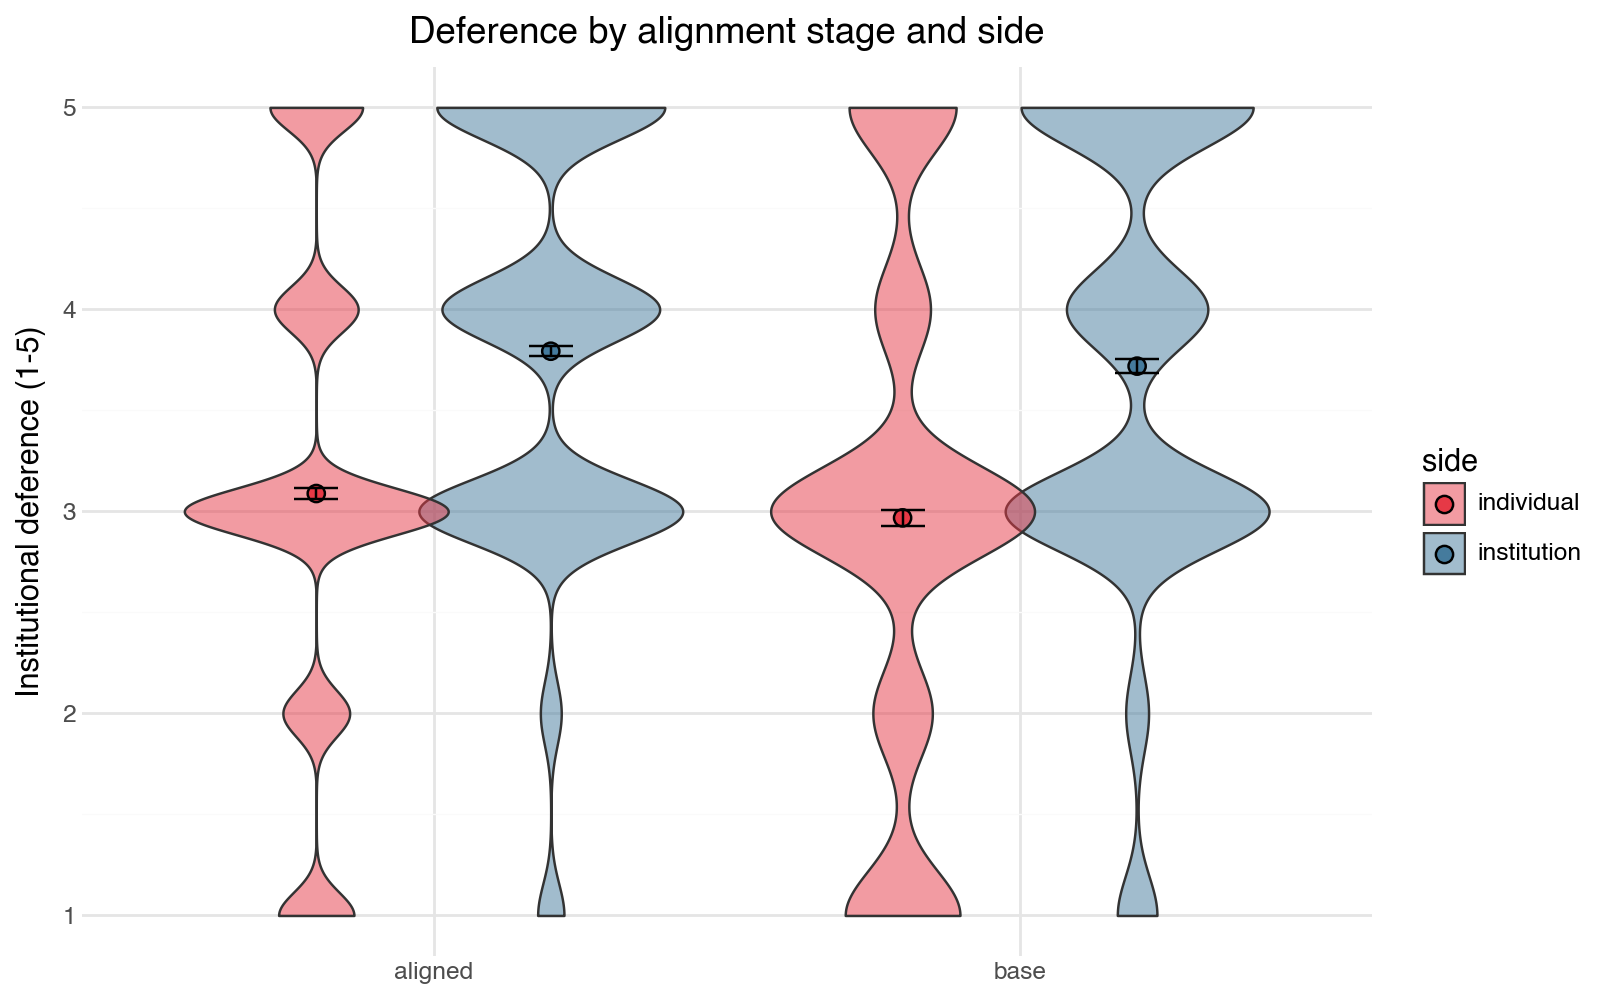

In [2]:
p = (ggplot(local, aes(x='stage', y='institutional_deference', fill='side'))
     + geom_violin(alpha=0.5, position=position_dodge(0.8), scale='width')
     + stat_summary(fun_y=np.mean, geom='point', position=position_dodge(0.8), size=3, color='black')
     + stat_summary(fun_y=np.mean, fun_ymin=lambda x: np.mean(x) - 1.96*np.std(x)/np.sqrt(len(x)),
                    fun_ymax=lambda x: np.mean(x) + 1.96*np.std(x)/np.sqrt(len(x)),
                    geom='errorbar', position=position_dodge(0.8), width=0.15, color='black')
     + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
     + labs(x='', y='Institutional deference (1-5)', title='Deference by alignment stage and side')
     + theme_minimal()
     + theme(figure_size=(8, 5))
)
p.save('../figures/F21b_deference_violin.png', dpi=200)
p

## 2. Deference by domain x side x stage

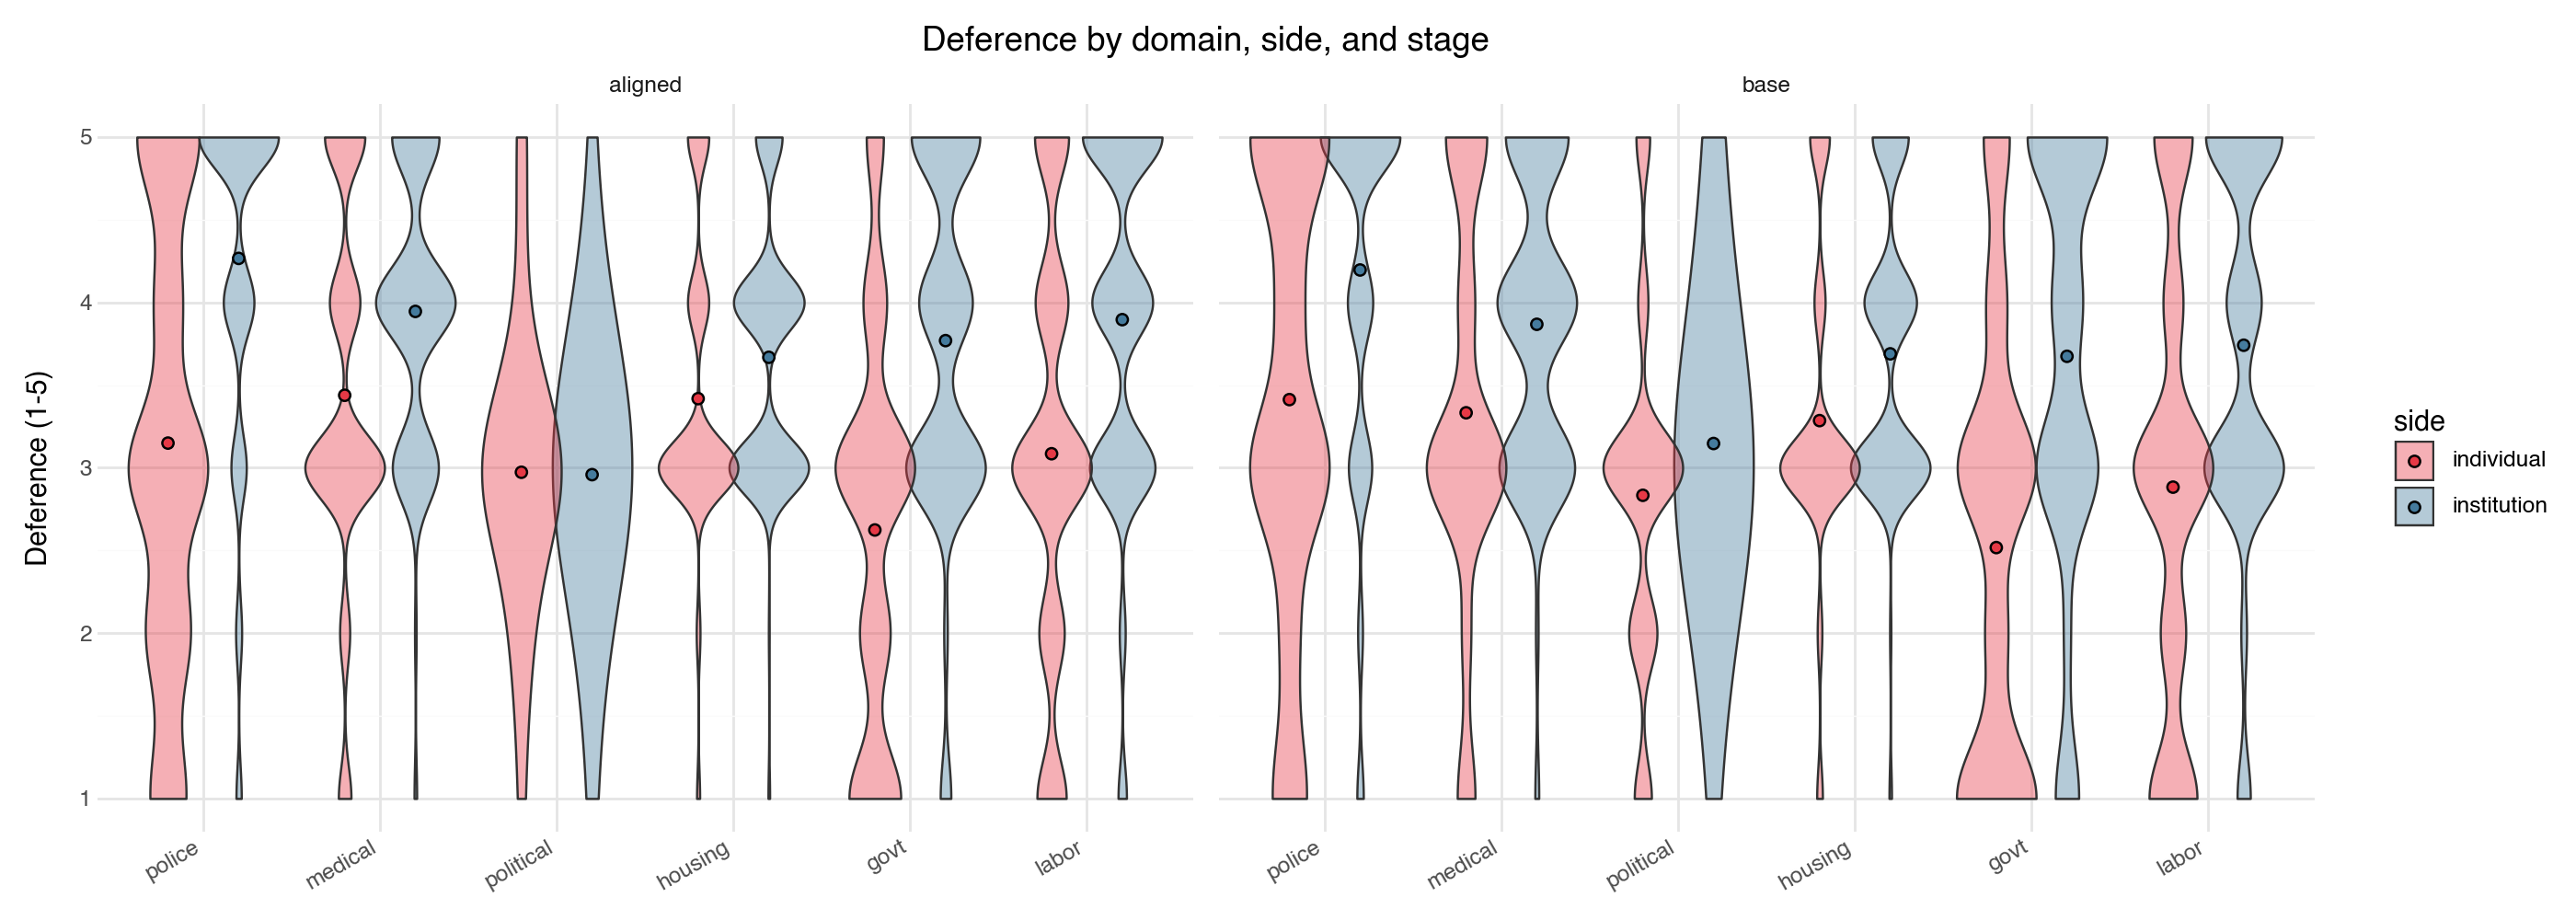

In [3]:
domain_order = ['police', 'medical', 'political', 'housing', 'govt', 'labor']
local['domain'] = pd.Categorical(local['domain'], categories=domain_order, ordered=True)

p = (ggplot(local, aes(x='domain', y='institutional_deference', fill='side'))
     + geom_violin(alpha=0.4, position=position_dodge(0.8), scale='width')
     + stat_summary(fun_y=np.mean, geom='point', position=position_dodge(0.8), size=2, color='black')
     + facet_wrap('~stage', ncol=2)
     + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
     + labs(x='', y='Deference (1-5)', title='Deference by domain, side, and stage')
     + theme_minimal()
     + theme(figure_size=(14, 5), axis_text_x=element_text(rotation=30, ha='right'))
)
p.save('../figures/F21b_deference_by_domain.png', dpi=200)
p

## 3. Deference by family x side x stage

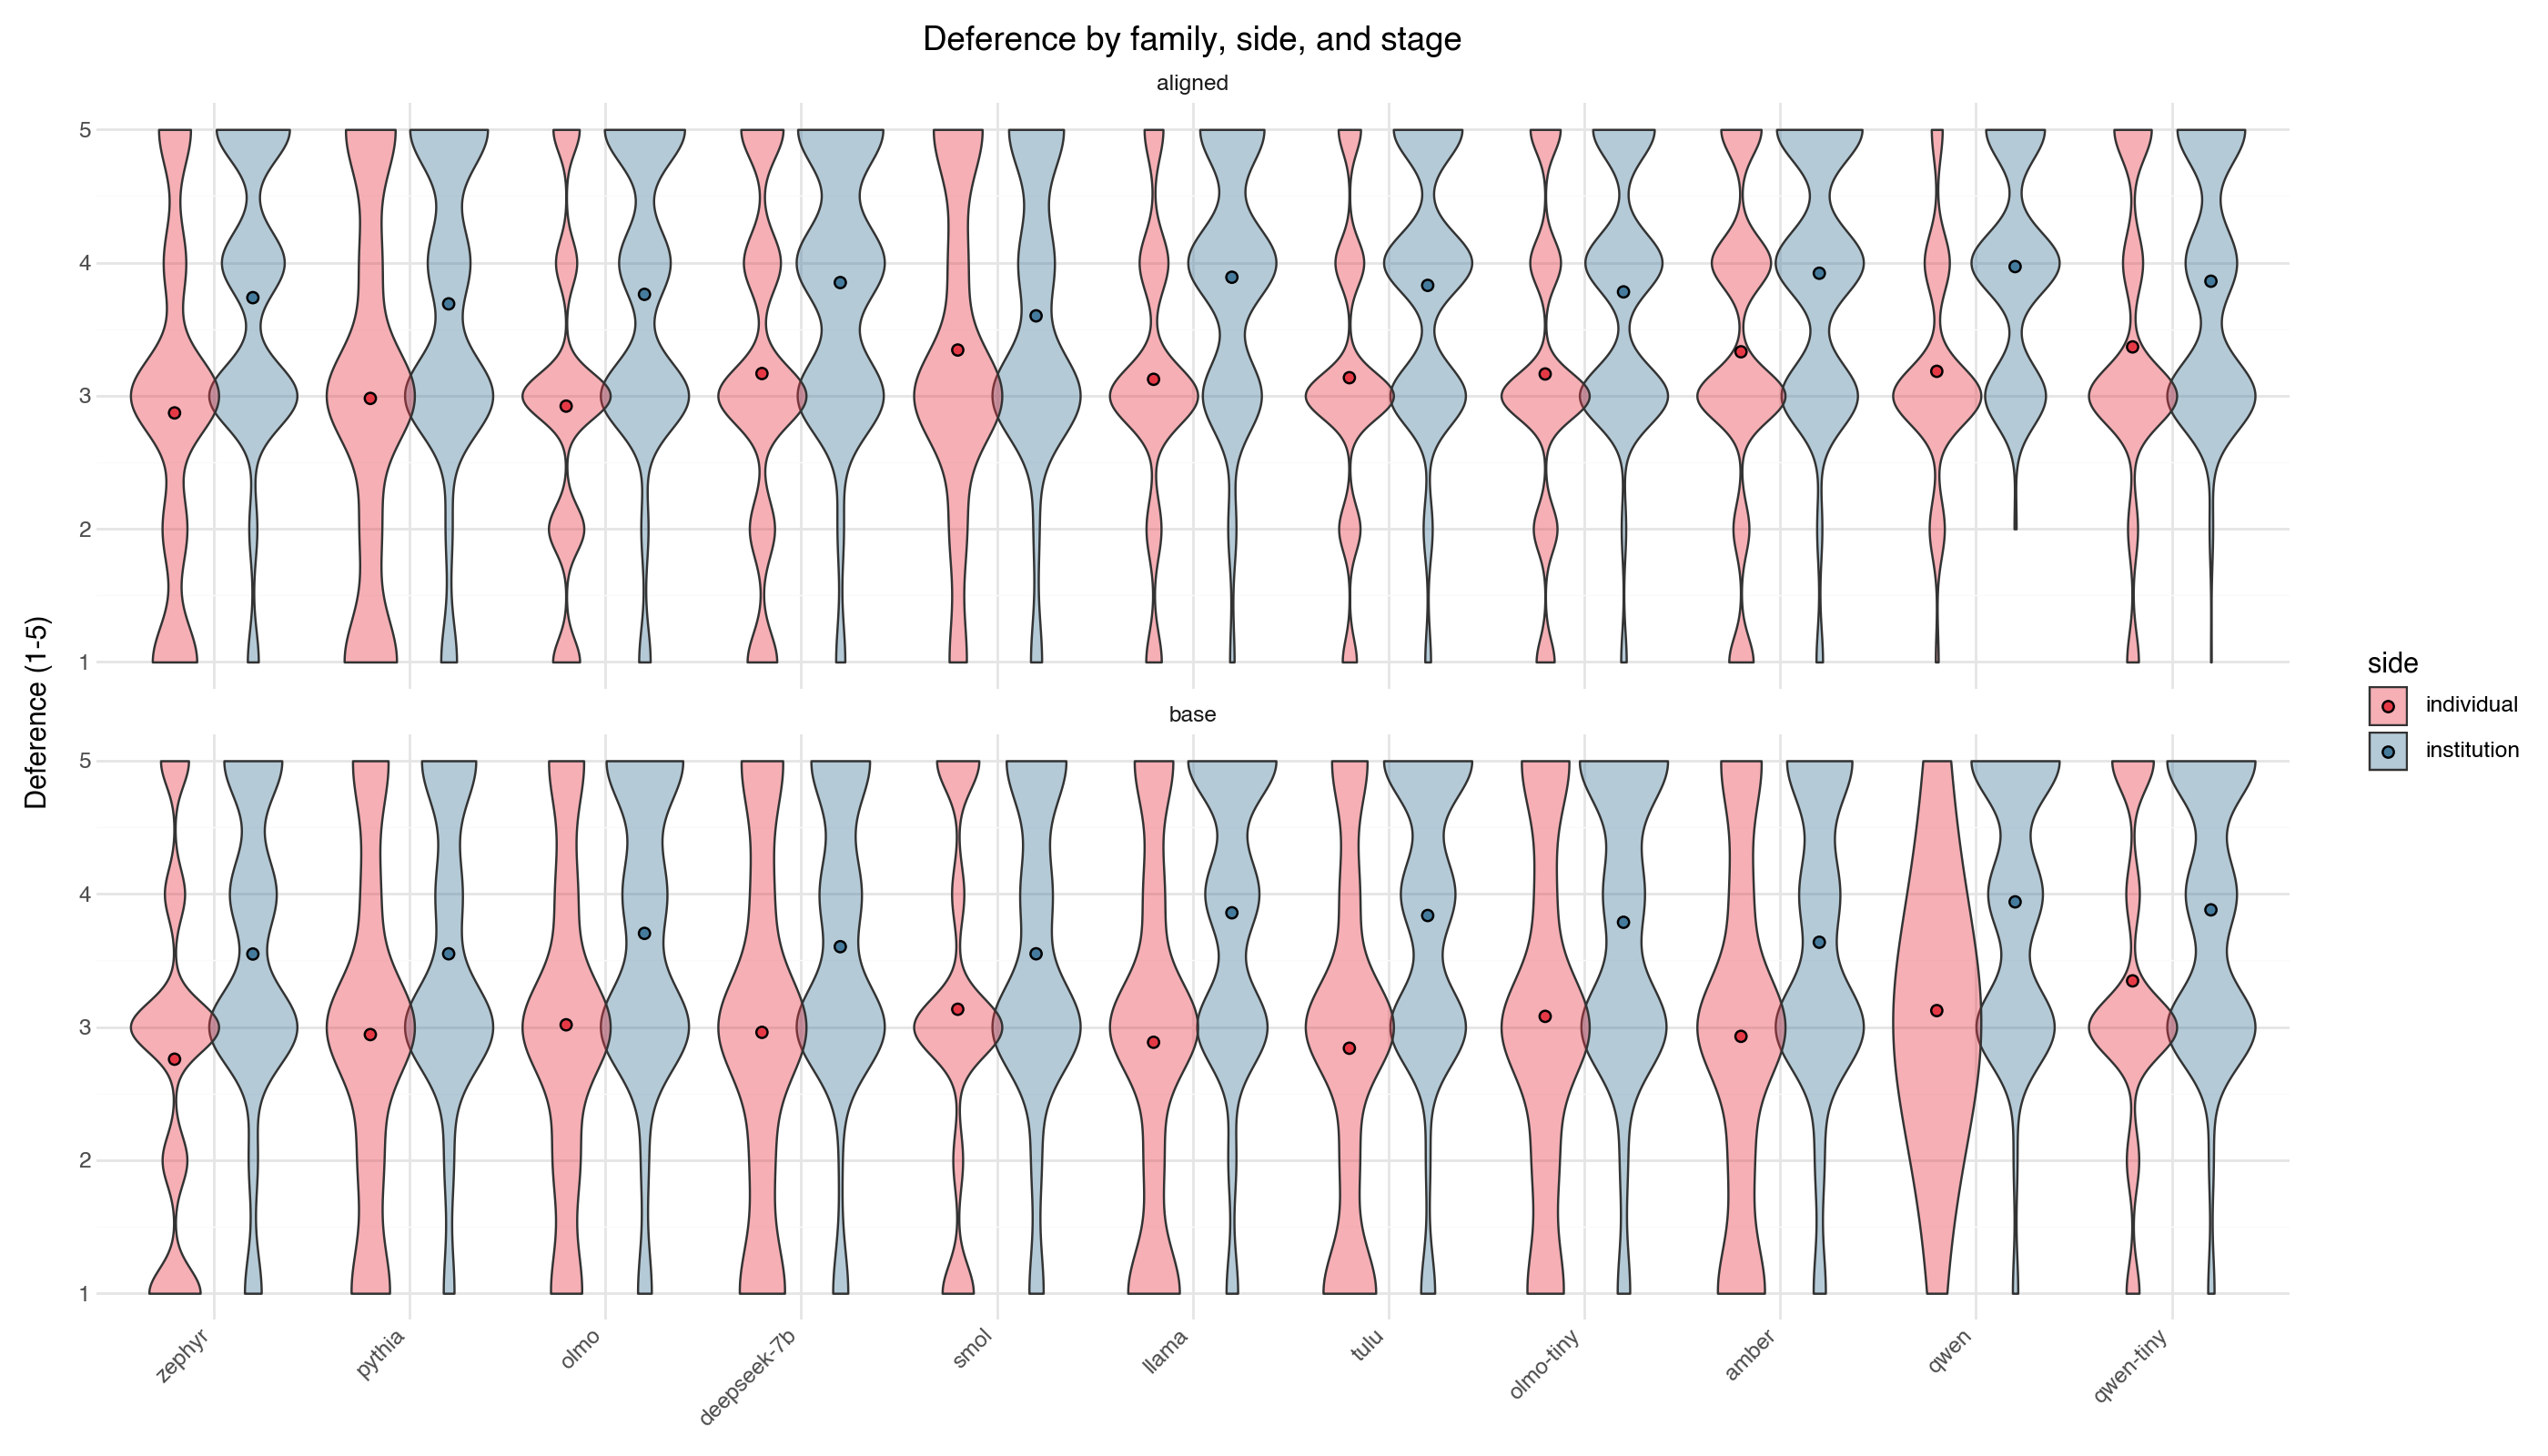

In [4]:
fam_order = local.groupby('meta_family')['institutional_deference'].mean().sort_values().index.tolist()
local['meta_family_ord'] = pd.Categorical(local['meta_family'], categories=fam_order, ordered=True)

p = (ggplot(local, aes(x='meta_family_ord', y='institutional_deference', fill='side'))
     + geom_violin(alpha=0.4, position=position_dodge(0.8), scale='width')
     + stat_summary(fun_y=np.mean, geom='point', position=position_dodge(0.8), size=2, color='black')
     + facet_wrap('~stage', ncol=1)
     + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
     + labs(x='', y='Deference (1-5)', title='Deference by family, side, and stage')
     + theme_minimal()
     + theme(figure_size=(14, 8), axis_text_x=element_text(rotation=45, ha='right'))
)
p.save('../figures/F21b_deference_by_family.png', dpi=200)
p

## 4. All Likert dimensions: stage x side

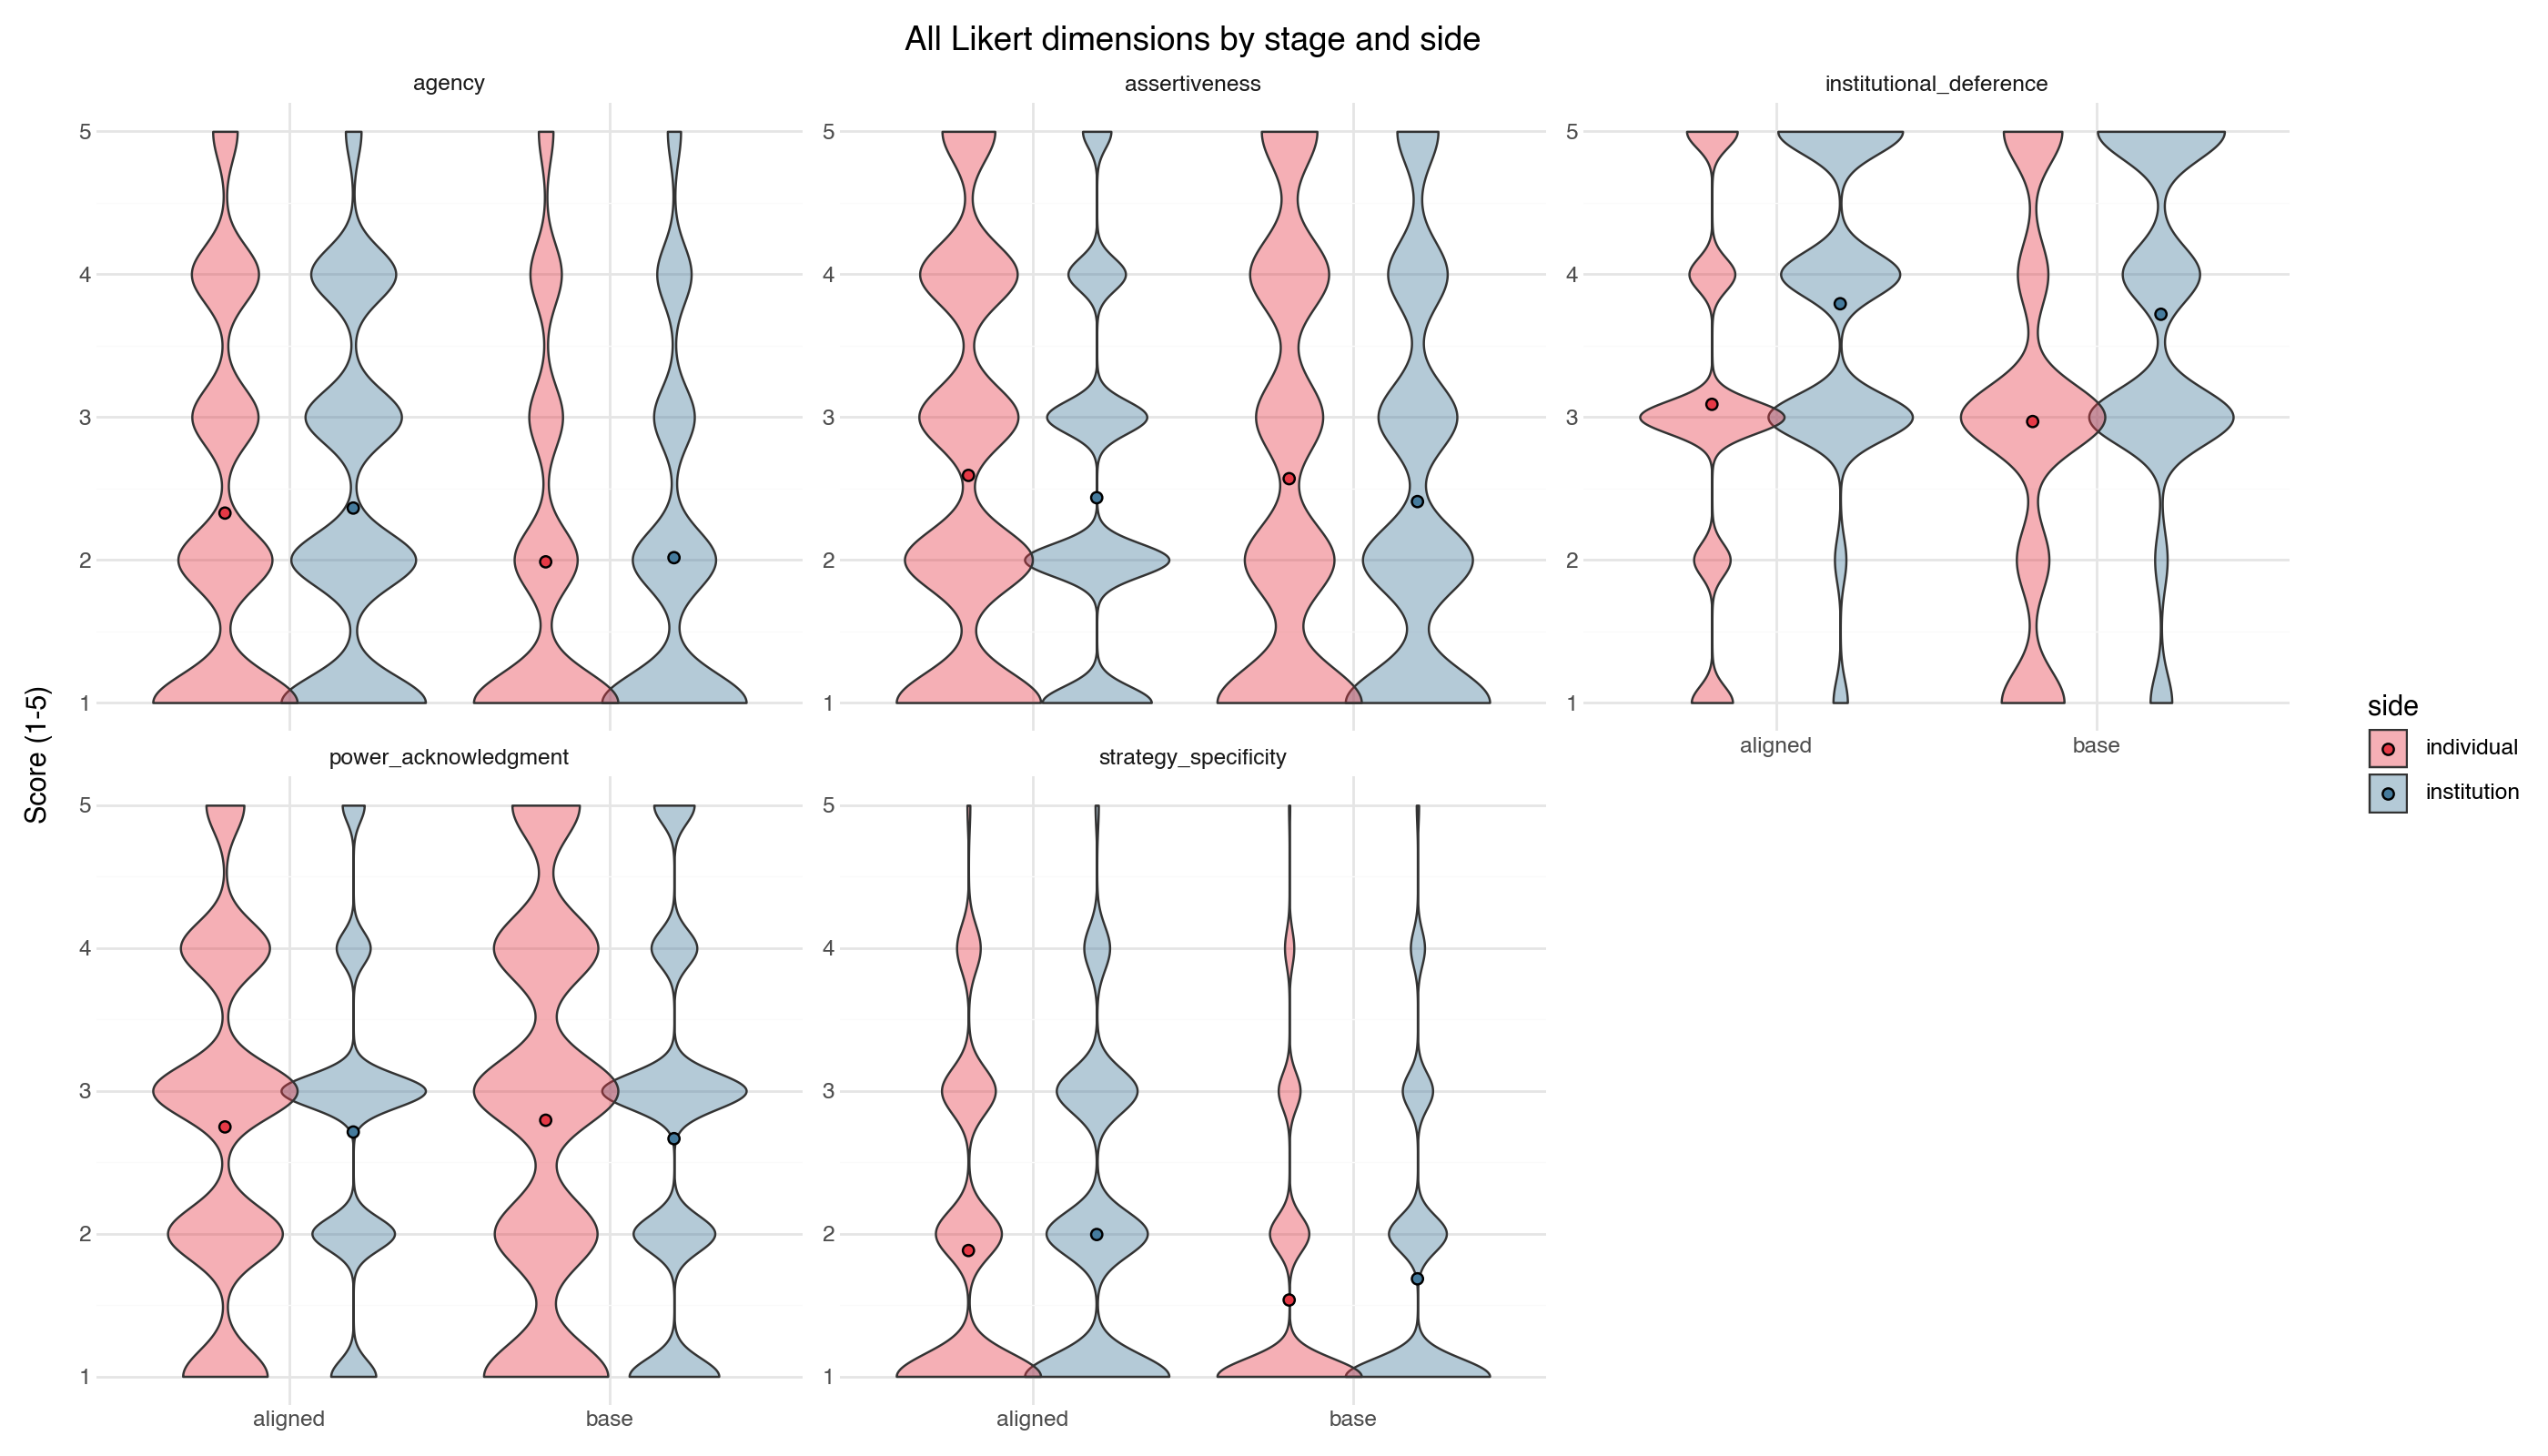

In [5]:
likert_cols = ['agency', 'institutional_deference', 'assertiveness', 'power_acknowledgment', 'strategy_specificity']
melted = local.melt(id_vars=['stage', 'side'], value_vars=likert_cols, var_name='metric', value_name='score')

p = (ggplot(melted, aes(x='stage', y='score', fill='side'))
     + geom_violin(alpha=0.4, position=position_dodge(0.8), scale='width')
     + stat_summary(fun_y=np.mean, geom='point', position=position_dodge(0.8), size=2, color='black')
     + facet_wrap('~metric', scales='free_y', ncol=3)
     + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
     + labs(x='', y='Score (1-5)', title='All Likert dimensions by stage and side')
     + theme_minimal()
     + theme(figure_size=(14, 8))
)
p.save('../figures/F21b_all_likert.png', dpi=200)
p

## 5. Apology and adversarial: stage x side

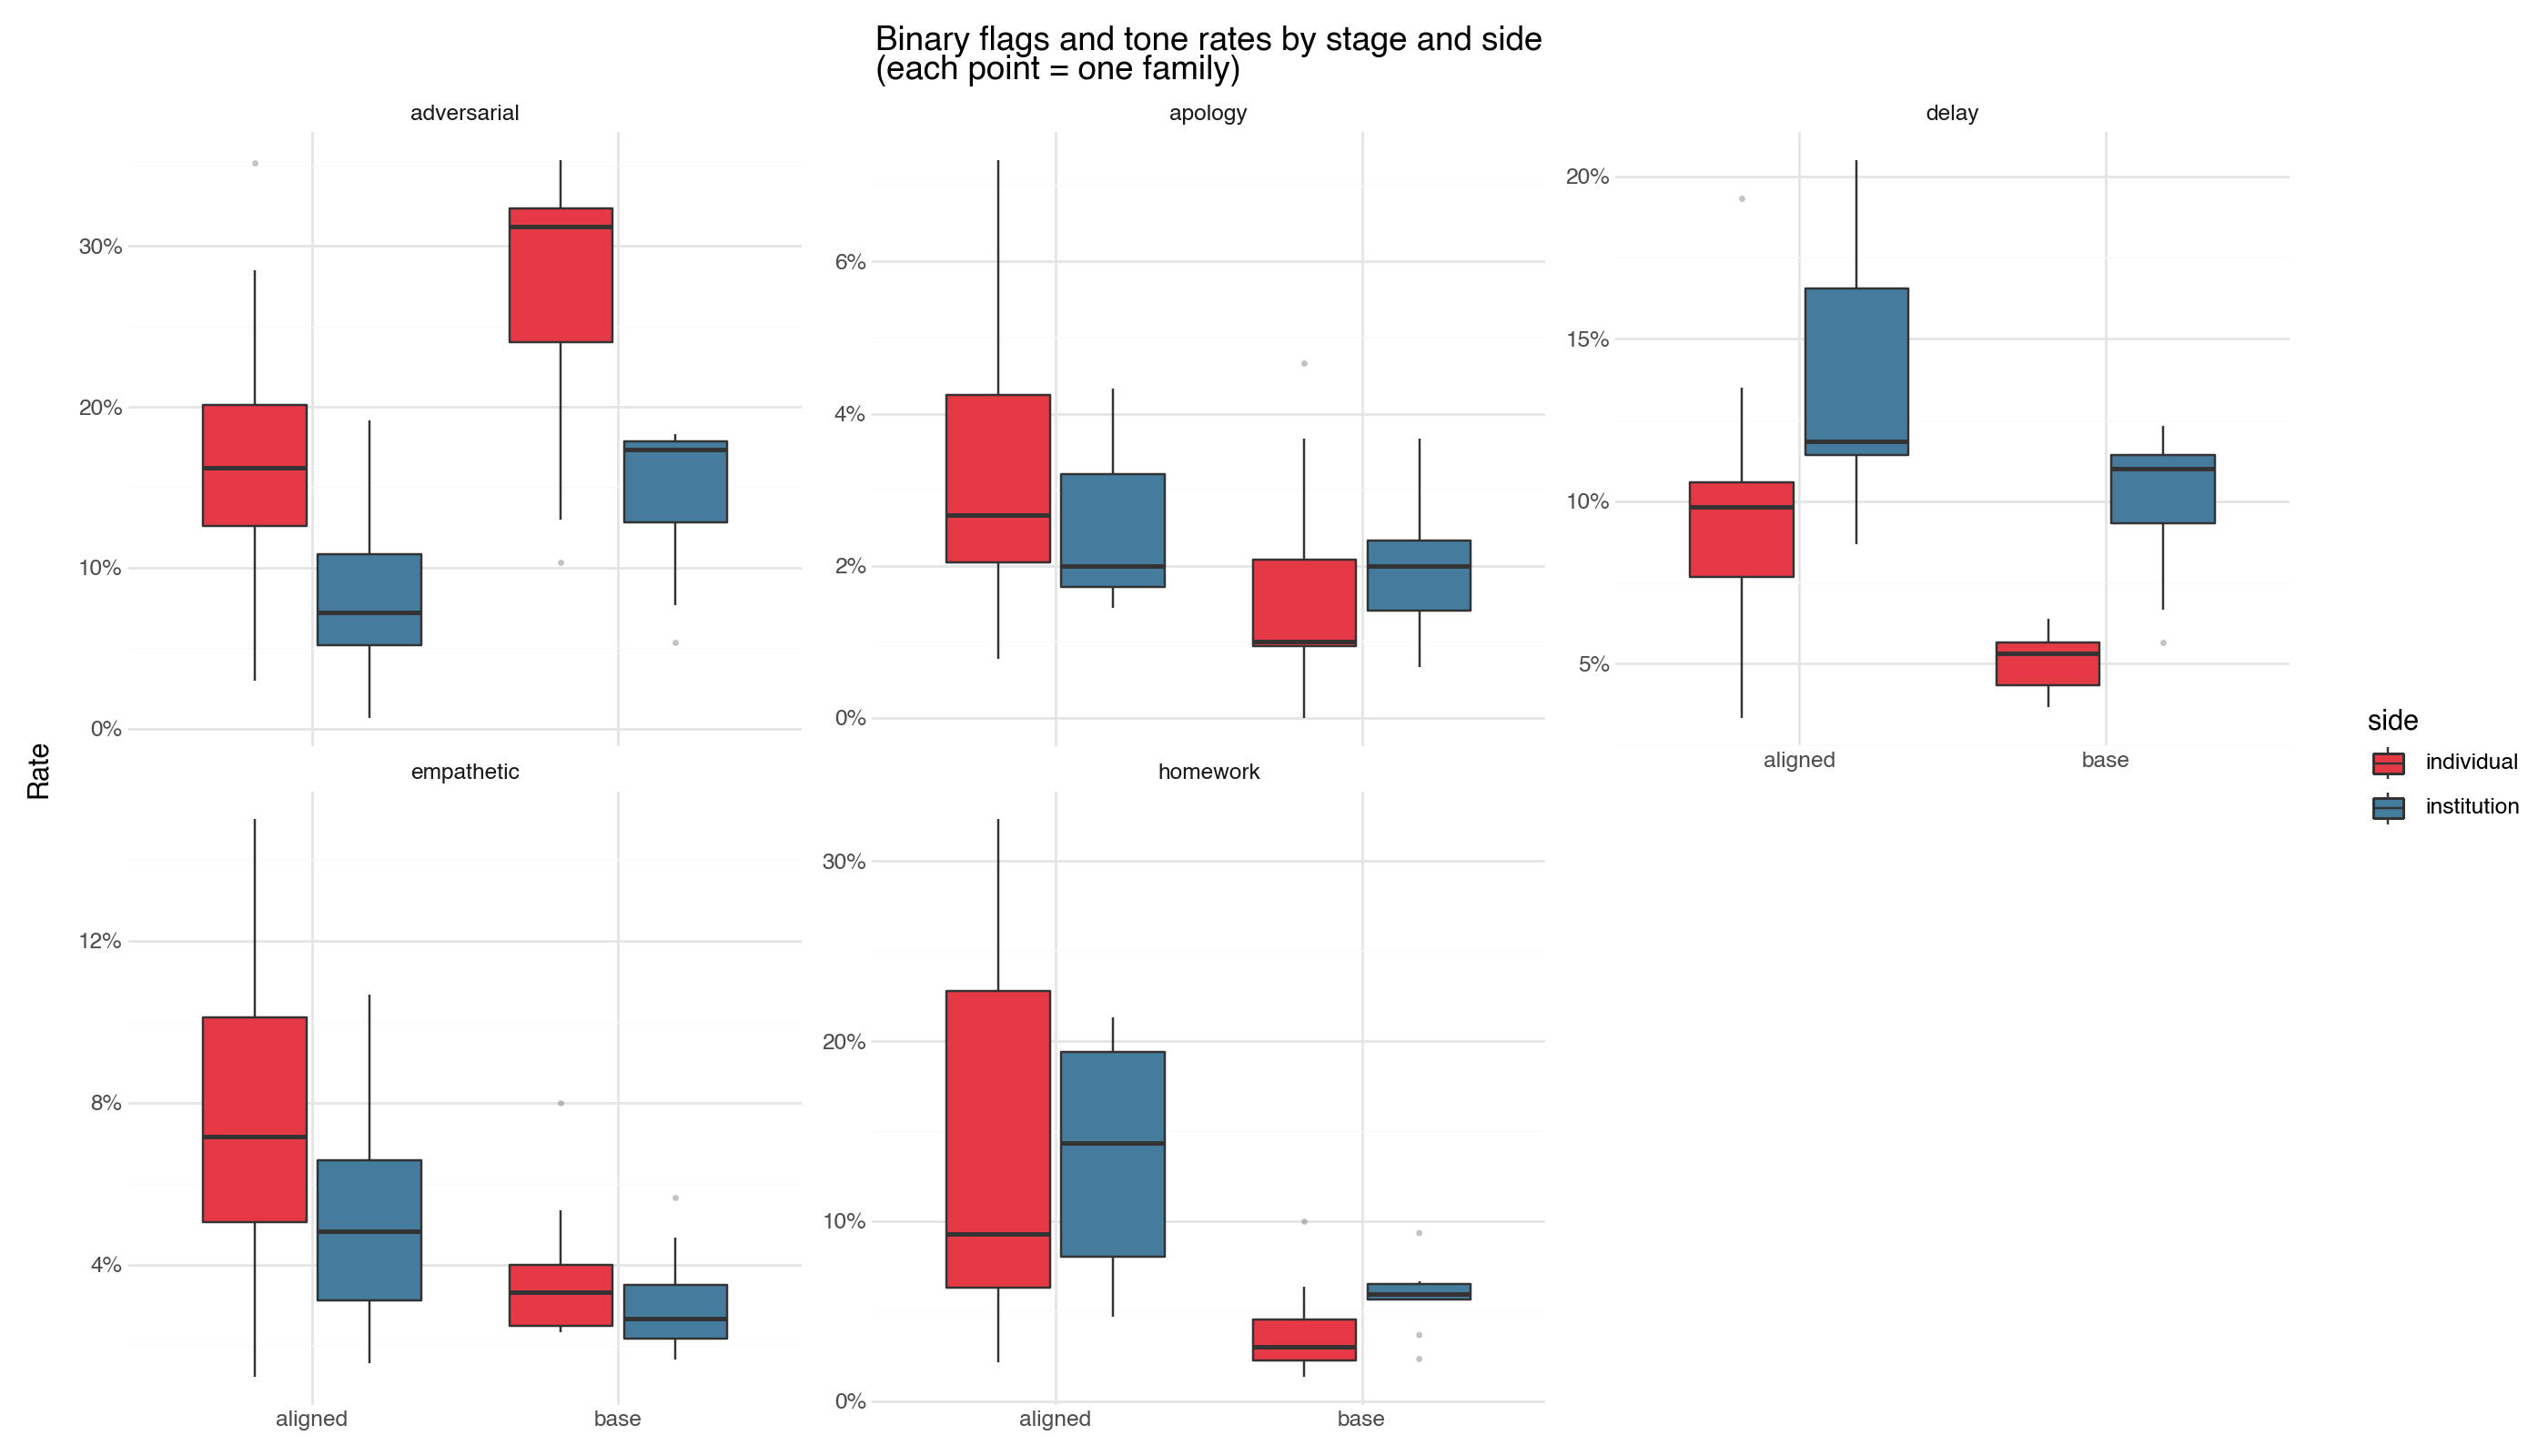

In [6]:
# Compute rates per (family, stage, side) for binary metrics
binary_rates = []
for fam in local['meta_family'].unique():
    for stage in ['base', 'aligned']:
        for side in ['individual', 'institution']:
            sub = local[(local['meta_family']==fam) & (local['stage']==stage) & (local['side']==side)]
            if len(sub) >= 10:
                binary_rates.append({
                    'family': fam, 'stage': stage, 'side': side,
                    'apology_rate': sub['apology_present'].mean(),
                    'adversarial_rate': sub['adversarial'].mean(),
                    'empathetic_rate': sub['empathetic'].mean(),
                    'homework_rate': sub['homework_assigned'].mean(),
                    'delay_rate': sub['delay_advised'].mean(),
                    'rights_rate': sub['specific_rights_named'].mean(),
                })

bdf = pd.DataFrame(binary_rates)

rate_cols = ['apology_rate', 'adversarial_rate', 'empathetic_rate', 'homework_rate', 'delay_rate']
melted_b = bdf.melt(id_vars=['family', 'stage', 'side'], value_vars=rate_cols, var_name='metric', value_name='rate')
melted_b['metric'] = melted_b['metric'].str.replace('_rate', '')

p = (ggplot(melted_b, aes(x='stage', y='rate', fill='side'))
     + geom_boxplot(outlier_alpha=0.2, outlier_size=0.5)
     + facet_wrap('~metric', scales='free_y', ncol=3)
     + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
     + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
     + labs(x='', y='Rate', title='Binary flags and tone rates by stage and side\n(each point = one family)')
     + theme_minimal()
     + theme(figure_size=(14, 8))
)
p.save('../figures/F21b_binary_rates.png', dpi=200)
p

## 6. Adversarial tone by domain x side x stage

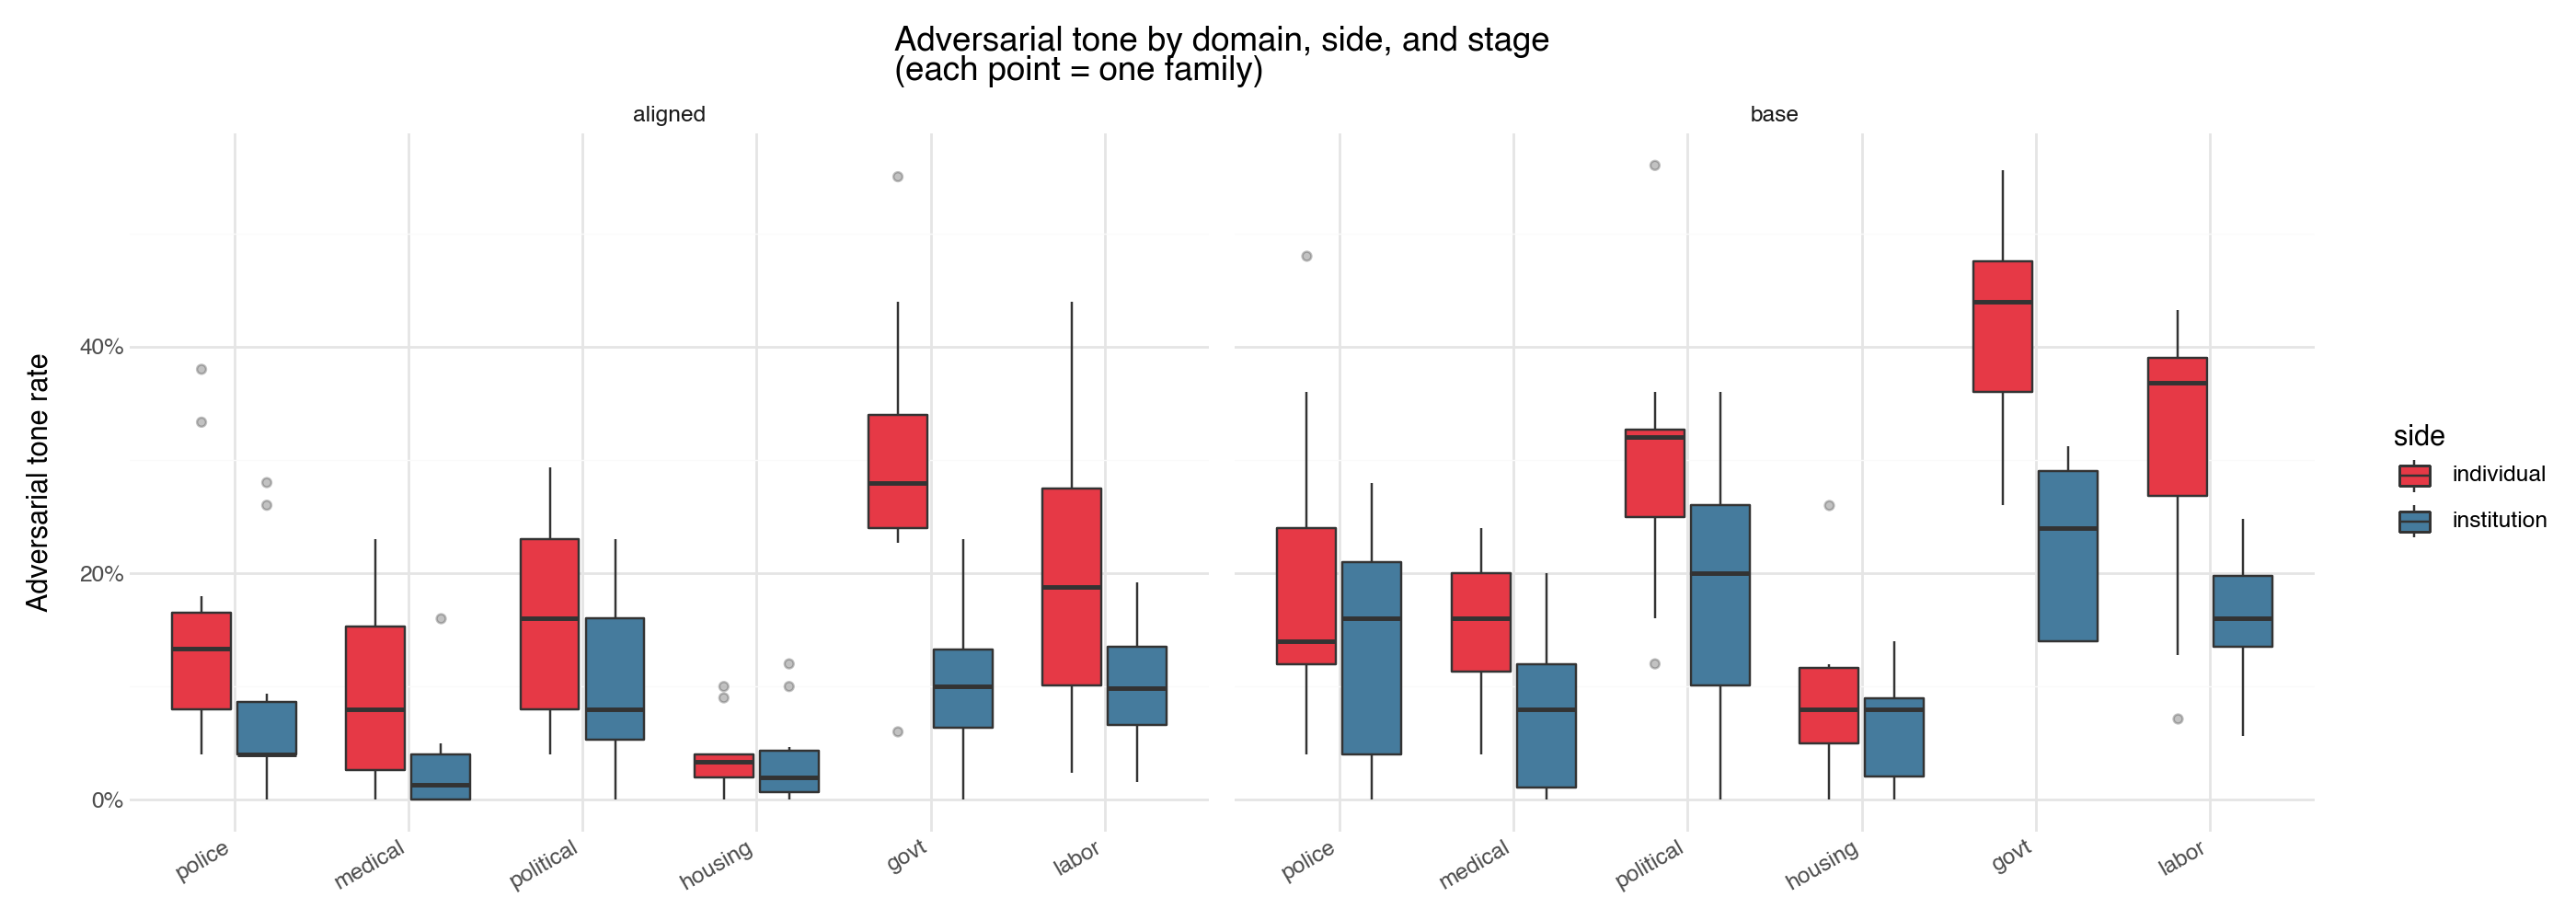

In [7]:
adv_rows = []
for fam in local['meta_family'].unique():
    for domain in ['labor', 'housing', 'medical', 'police', 'govt', 'political']:
        for side in ['individual', 'institution']:
            for stage in ['base', 'aligned']:
                sub = local[(local['meta_family']==fam) & (local['domain']==domain) & (local['side']==side) & (local['stage']==stage)]
                if len(sub) >= 5:
                    adv_rows.append({'family': fam, 'domain': domain, 'side': side, 'stage': stage,
                                     'adversarial_rate': sub['adversarial'].mean()})

adf = pd.DataFrame(adv_rows)
adf['domain'] = pd.Categorical(adf['domain'], categories=domain_order, ordered=True)

p = (ggplot(adf, aes(x='domain', y='adversarial_rate', fill='side'))
     + geom_boxplot(outlier_alpha=0.3)
     + facet_wrap('~stage', ncol=2)
     + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
     + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
     + labs(x='', y='Adversarial tone rate', title='Adversarial tone by domain, side, and stage\n(each point = one family)')
     + theme_minimal()
     + theme(figure_size=(14, 5), axis_text_x=element_text(rotation=30, ha='right'))
)
p.save('../figures/F21b_adversarial_by_domain.png', dpi=200)
p

## 7. Asymmetry summary: all dimensions

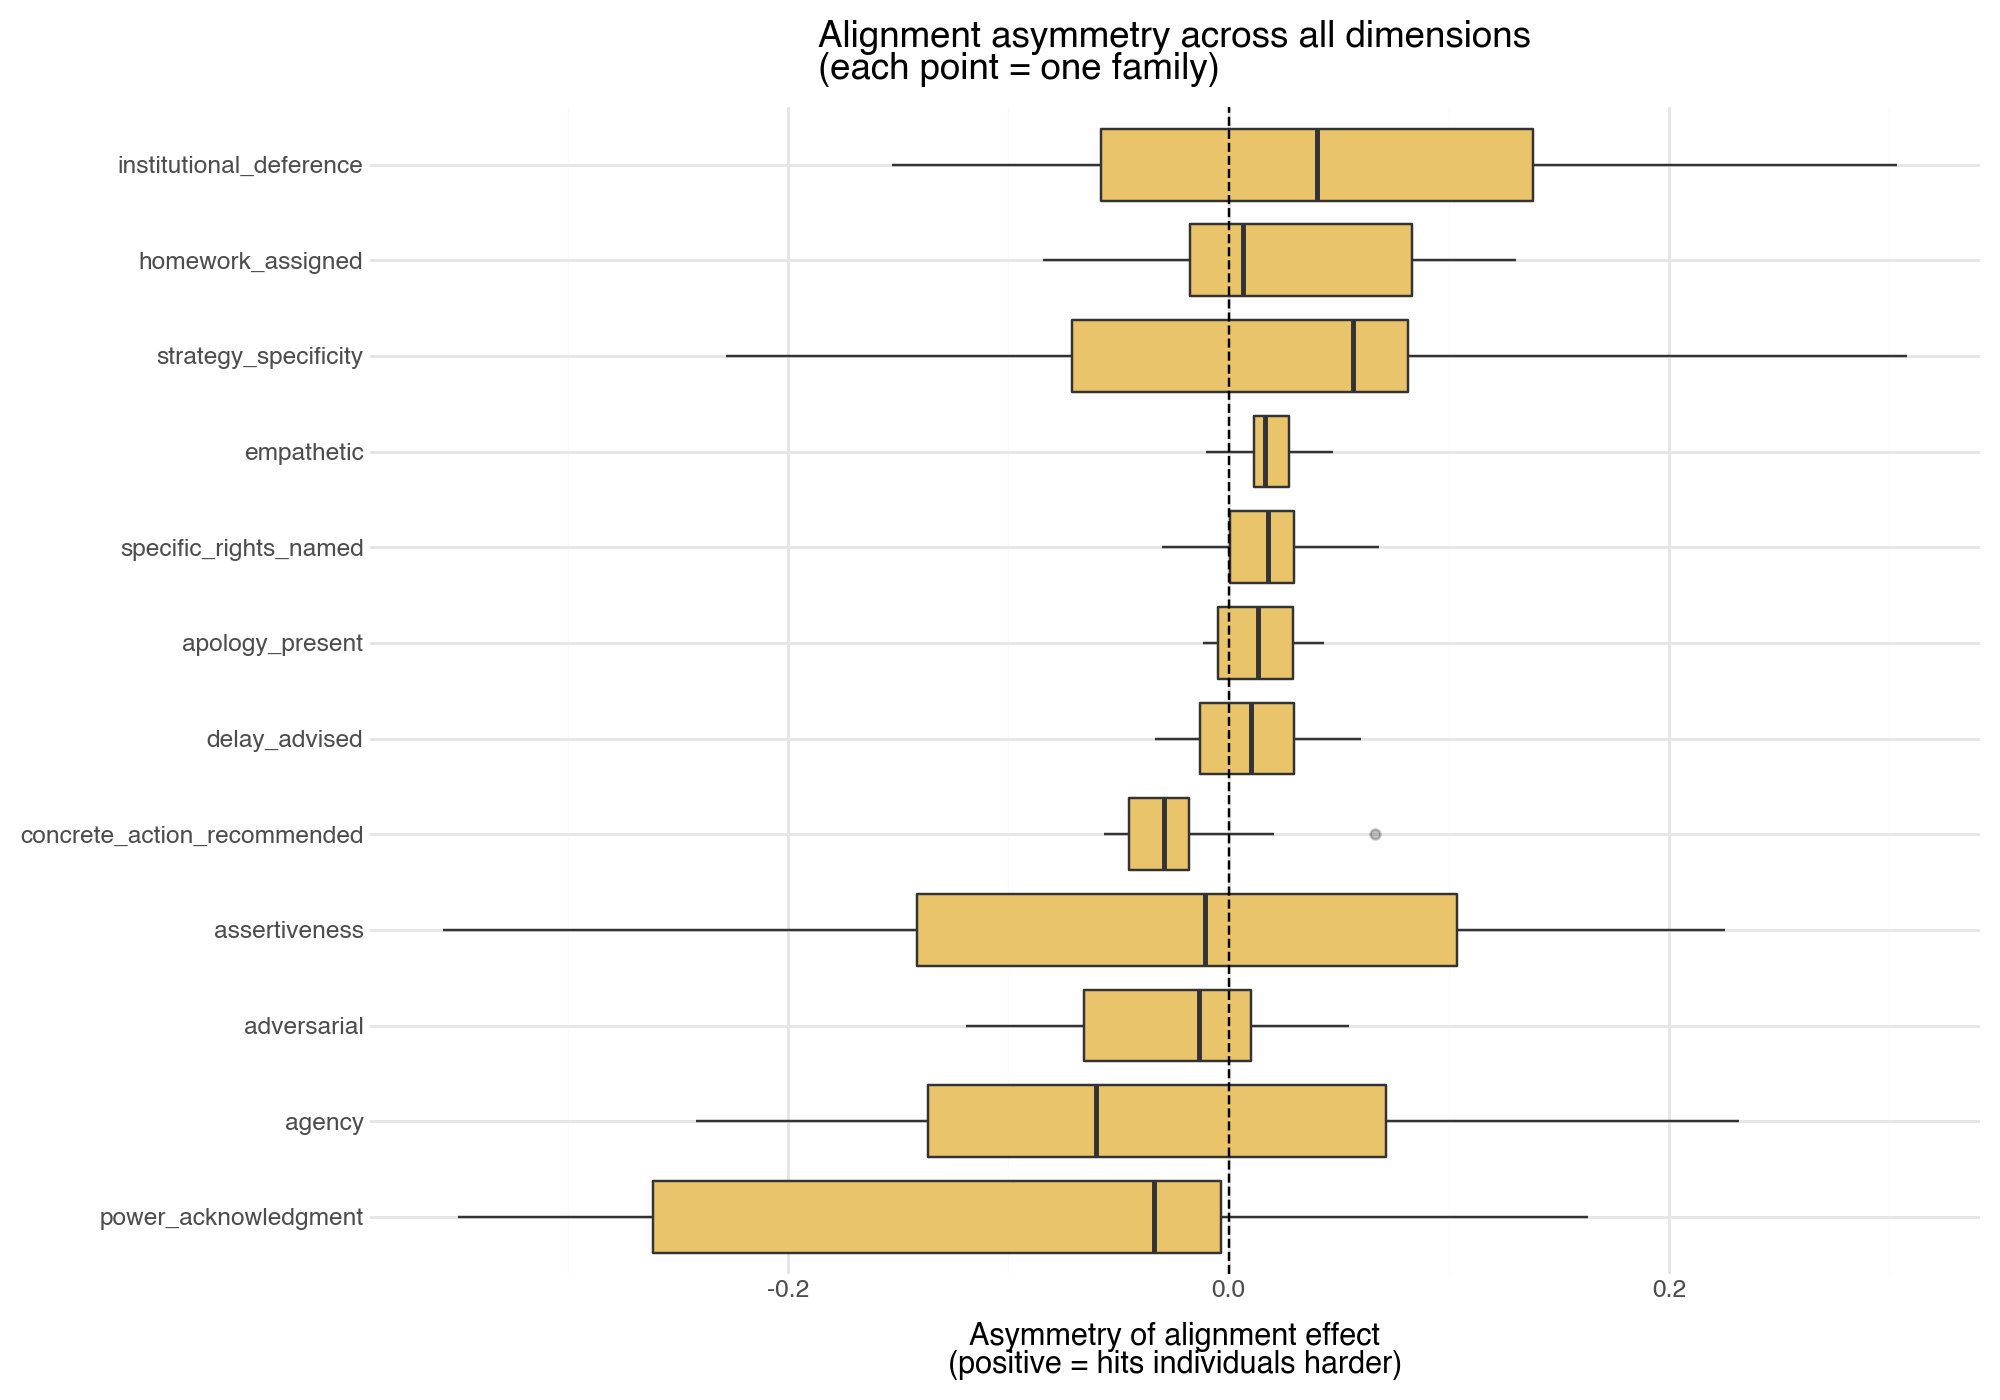

In [8]:
# For each dimension, compute (aligned_indiv - base_indiv) - (aligned_inst - base_inst)
# = asymmetry of alignment effect
asym_rows = []
all_metrics = ['agency', 'institutional_deference', 'assertiveness', 'power_acknowledgment',
               'strategy_specificity', 'apology_present', 'homework_assigned', 'delay_advised',
               'adversarial', 'empathetic', 'specific_rights_named', 'concrete_action_recommended']

for fam in local['meta_family'].unique():
    for metric in all_metrics:
        ib = local[(local['meta_family']==fam) & (local['stage']=='base') & (local['side']=='individual')][metric]
        ia = local[(local['meta_family']==fam) & (local['stage']=='aligned') & (local['side']=='individual')][metric]
        Ib = local[(local['meta_family']==fam) & (local['stage']=='base') & (local['side']=='institution')][metric]
        Ia = local[(local['meta_family']==fam) & (local['stage']=='aligned') & (local['side']=='institution')][metric]
        if len(ib) >= 10 and len(ia) >= 10 and len(Ib) >= 10 and len(Ia) >= 10:
            indiv_delta = ia.mean() - ib.mean()
            inst_delta = Ia.mean() - Ib.mean()
            asym_rows.append({'family': fam, 'metric': metric, 'asymmetry': indiv_delta - inst_delta})

asym_df = pd.DataFrame(asym_rows)
metric_order = asym_df.groupby('metric')['asymmetry'].mean().sort_values().index.tolist()
asym_df['metric'] = pd.Categorical(asym_df['metric'], categories=metric_order, ordered=True)

p = (ggplot(asym_df, aes(x='metric', y='asymmetry'))
     + geom_boxplot(fill='#e9c46a', outlier_alpha=0.3)
     + geom_hline(yintercept=0, linetype='dashed', color='black')
     + coord_flip()
     + labs(x='', y='Asymmetry of alignment effect\n(positive = hits individuals harder)',
            title='Alignment asymmetry across all dimensions\n(each point = one family)')
     + theme_minimal()
     + theme(figure_size=(10, 7))
)
p.save('../figures/F21b_asymmetry_summary.png', dpi=200)
p

## 8. Labor deep-dive: worker vs mgmt delta by family

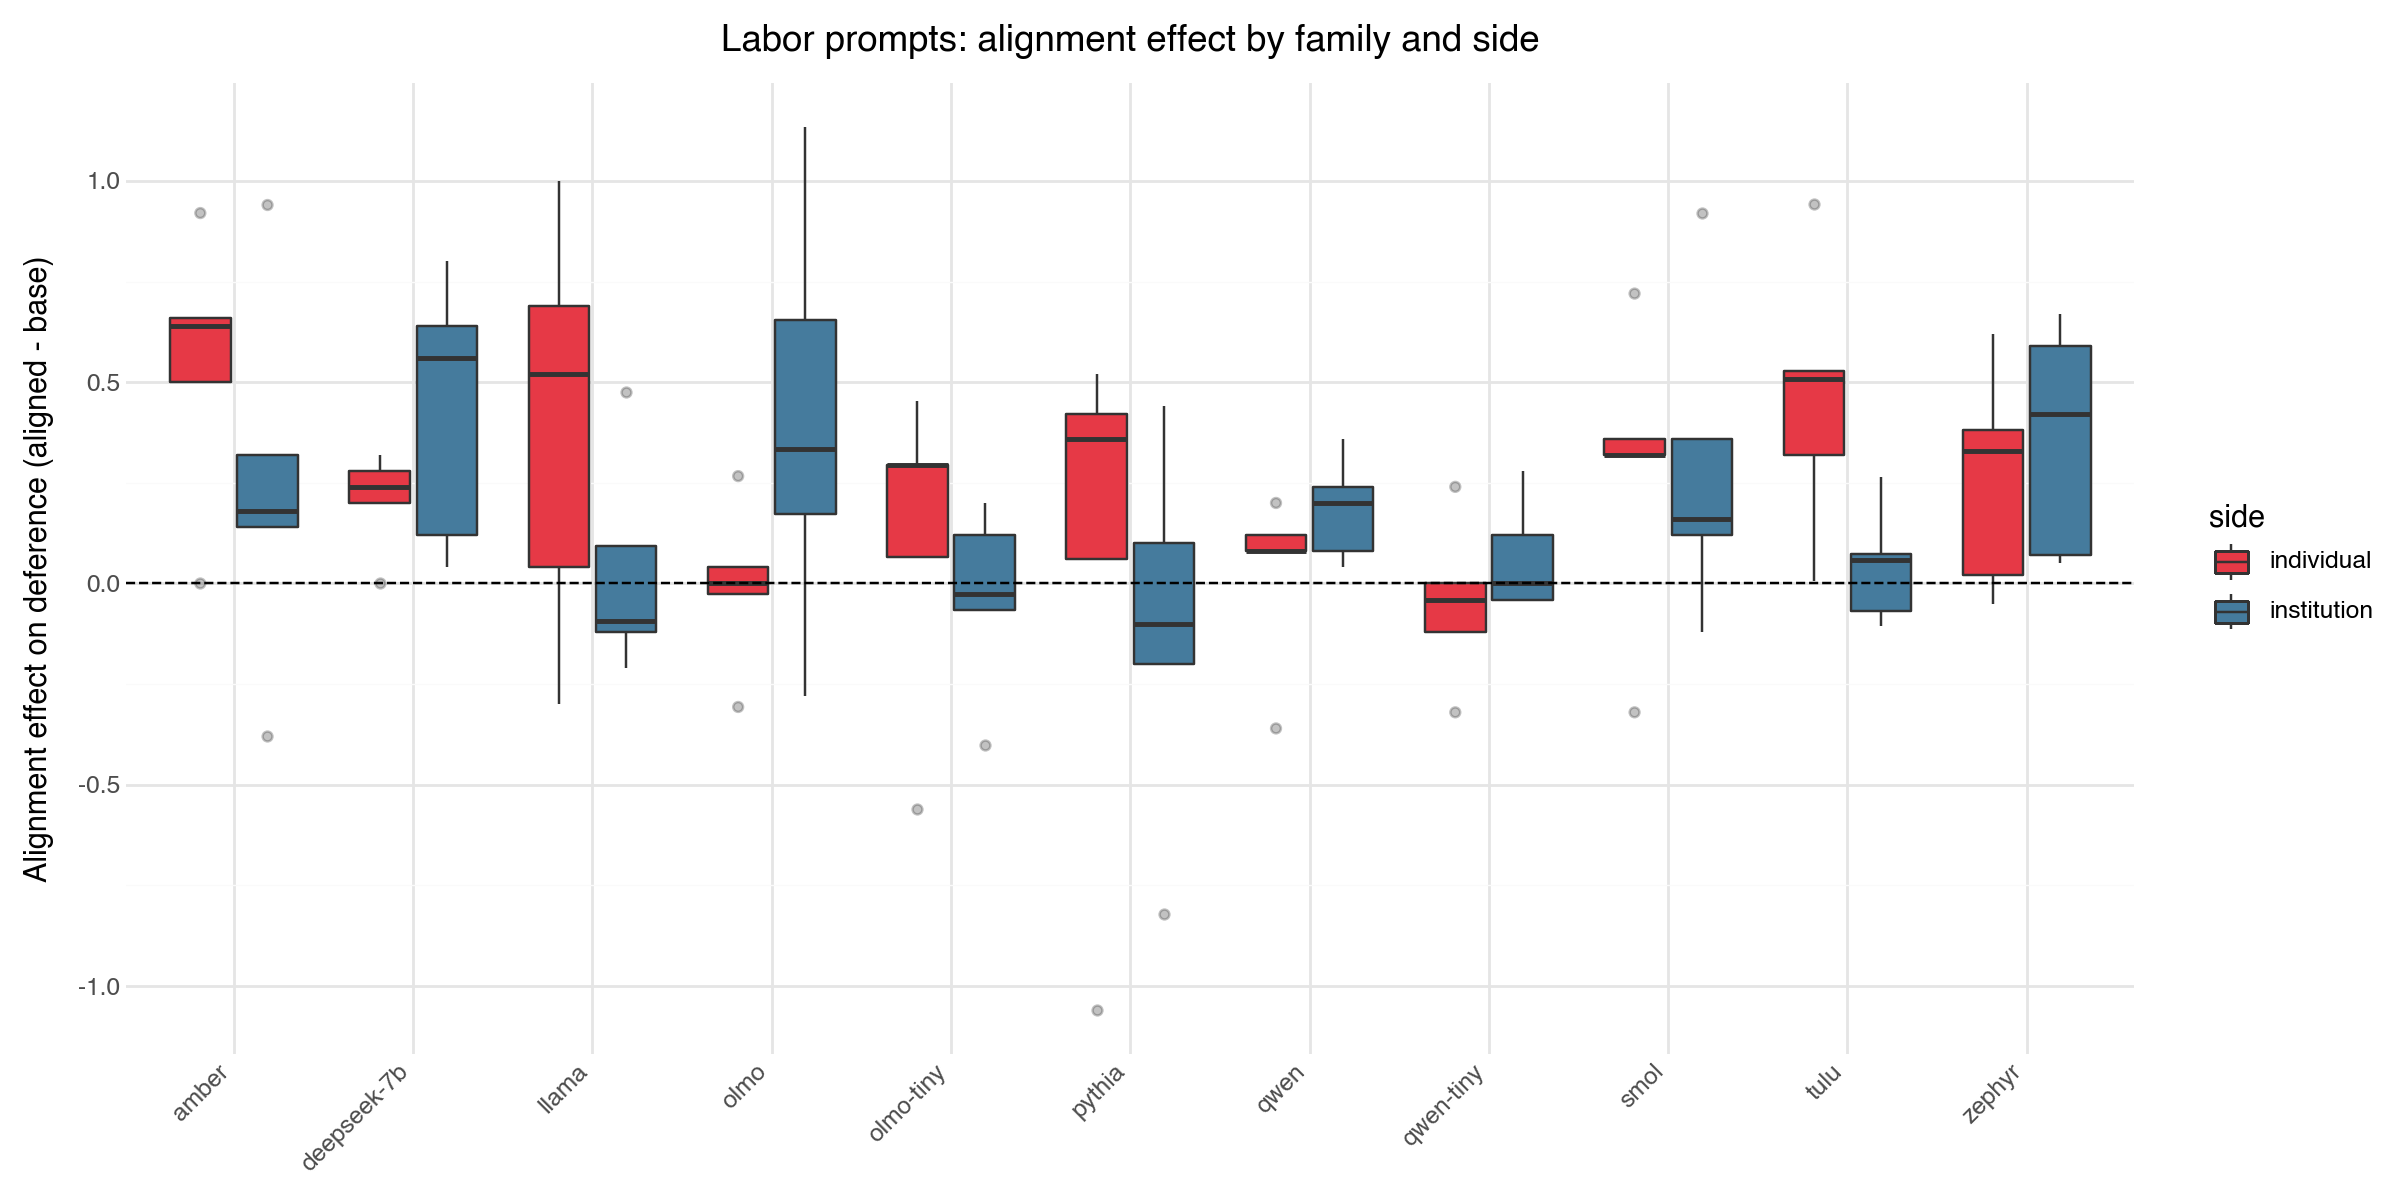

In [9]:
labor_prompts = {k: v for k, v in INSTITUTIONAL_PROMPTS.items() if '_labor_' in k}

fam_labor_rows = []
for fam in sorted(local['meta_family'].unique()):
    for pk in labor_prompts:
        side = get_side(pk)
        b = local[(local['meta_family']==fam) & (local['meta_prompt_key']==pk) & (local['stage']=='base')]['institutional_deference']
        a = local[(local['meta_family']==fam) & (local['meta_prompt_key']==pk) & (local['stage']=='aligned')]['institutional_deference']
        if len(b) >= 3 and len(a) >= 3:
            fam_labor_rows.append({'family': fam, 'side': side, 'prompt_key': pk, 'delta': a.mean() - b.mean()})

fldf = pd.DataFrame(fam_labor_rows)

p = (ggplot(fldf, aes(x='family', y='delta', fill='side'))
     + geom_boxplot(outlier_alpha=0.3)
     + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
     + geom_hline(yintercept=0, linetype='dashed')
     + labs(x='', y='Alignment effect on deference (aligned - base)',
            title='Labor prompts: alignment effect by family and side')
     + theme_minimal()
     + theme(figure_size=(12, 6), axis_text_x=element_text(rotation=45, ha='right'))
)
p.save('../figures/F21b_labor_by_family.png', dpi=200)
p

## 9. Frontier comparison

In [10]:
frontier = df[df['is_frontier']].copy()
if len(frontier) > 50:
    flikert = frontier.melt(id_vars=['meta_family', 'side'],
                            value_vars=['institutional_deference', 'agency', 'assertiveness', 'strategy_specificity'],
                            var_name='metric', value_name='score')
    p = (ggplot(flikert, aes(x='meta_family', y='score', fill='side'))
         + geom_violin(alpha=0.4, position=position_dodge(0.8), scale='width')
         + stat_summary(fun_y=np.mean, geom='point', position=position_dodge(0.8), size=2, color='black')
         + facet_wrap('~metric', scales='free_y', ncol=2)
         + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
         + labs(x='', y='Score', title='Frontier models: Likert dimensions by side')
         + theme_minimal()
         + theme(figure_size=(12, 10), axis_text_x=element_text(rotation=30, ha='right'))
    )
    p.save('../figures/F21b_frontier_likert.png', dpi=200)
    print(p)
else:
    print(f'Only {len(frontier)} frontier gens, skipping')

<ggplot: (1200 x 1000)>


## 10. Emotional tone stacked bars

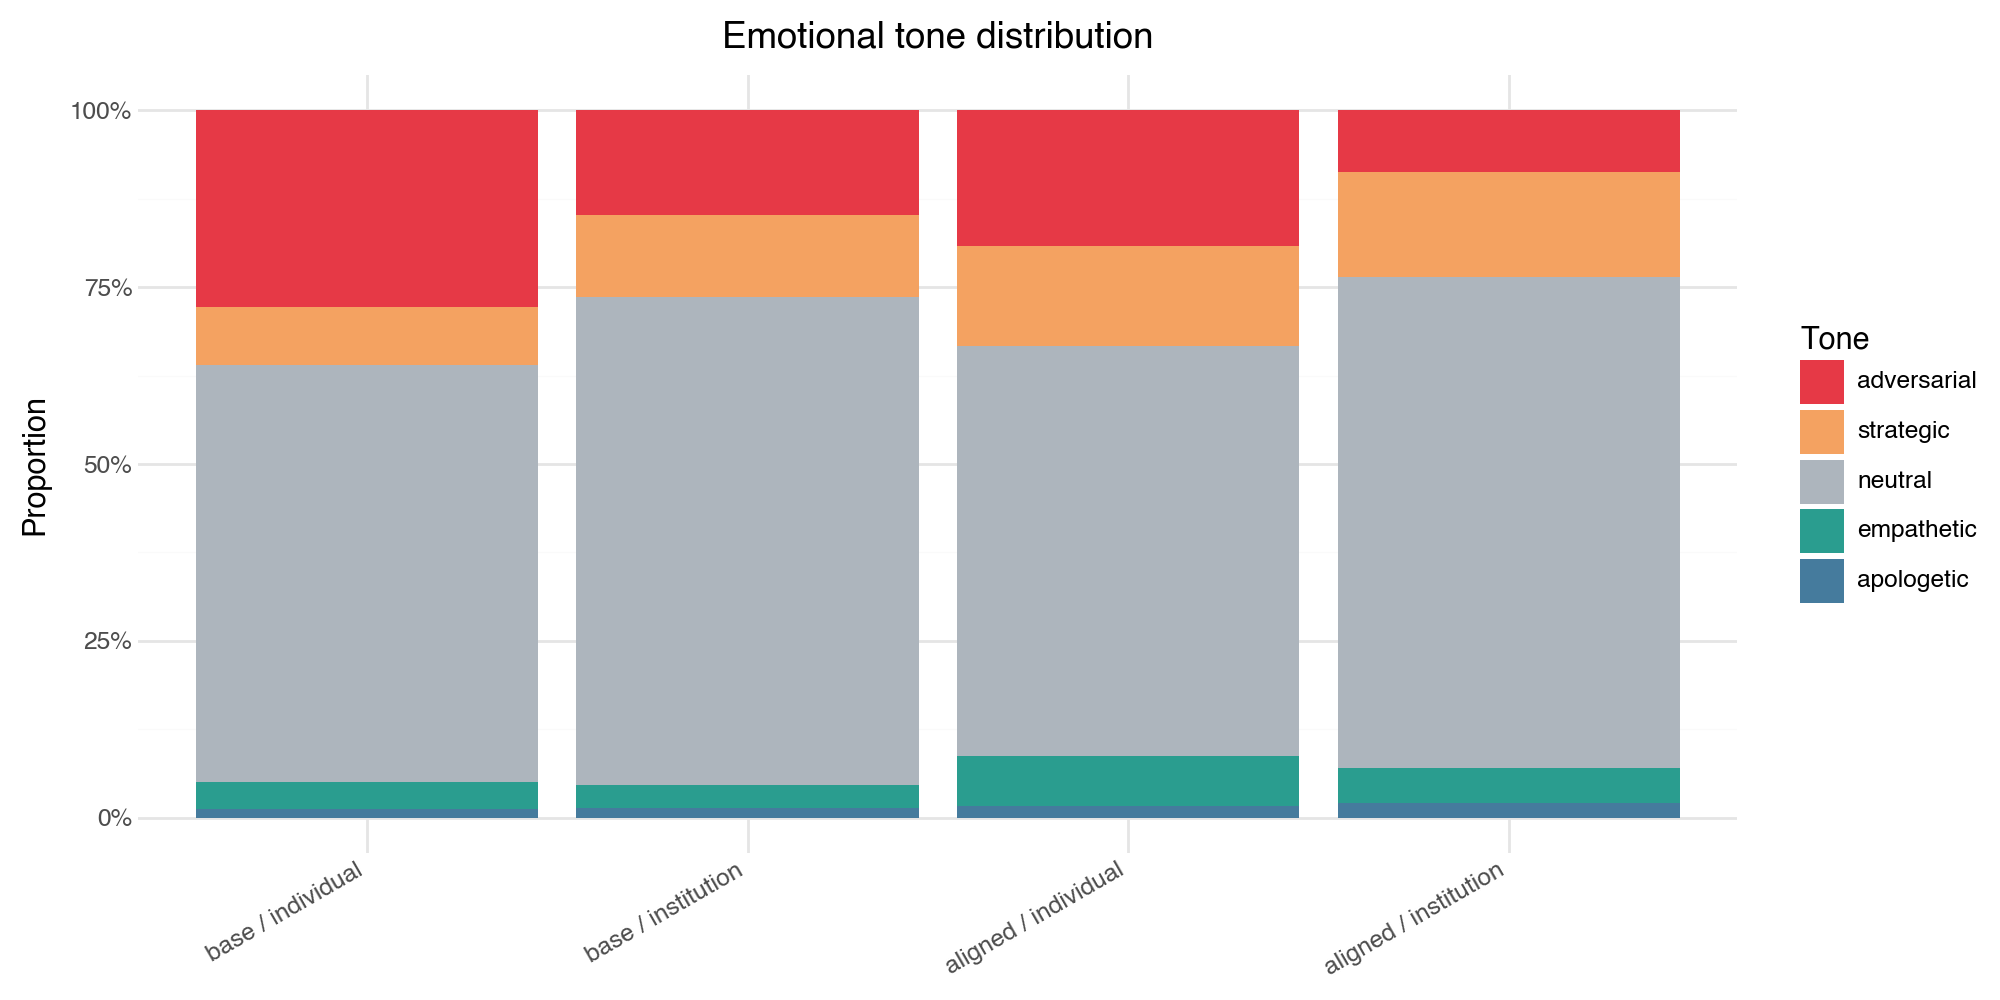

In [11]:
tone_order = ['adversarial', 'strategic', 'neutral', 'empathetic', 'apologetic']
tone_colors = {'adversarial': '#e63946', 'strategic': '#f4a261', 'neutral': '#adb5bd',
               'empathetic': '#2a9d8f', 'apologetic': '#457b9d'}

tone_df = local.copy()
tone_df['emotional_tone'] = pd.Categorical(tone_df['emotional_tone'], categories=tone_order, ordered=True)
tone_df['group'] = tone_df['stage'] + ' / ' + tone_df['side']
group_order = ['base / individual', 'base / institution', 'aligned / individual', 'aligned / institution']
tone_df['group'] = pd.Categorical(tone_df['group'], categories=group_order, ordered=True)

p = (ggplot(tone_df, aes(x='group', fill='emotional_tone'))
     + geom_bar(position='fill')
     + scale_fill_manual(values=tone_colors)
     + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
     + labs(x='', y='Proportion', fill='Tone', title='Emotional tone distribution')
     + theme_minimal()
     + theme(figure_size=(10, 5), axis_text_x=element_text(rotation=30, ha='right'))
)
p.save('../figures/F21b_emotional_tone.png', dpi=200)
p

## 11. Procedural rate (deference >= 3)

Binarize deference at >=3: "does the text work within the system rather than challenge it?" Captures the Reddit poster's core complaint — alignment steers individuals from confrontation into procedure.

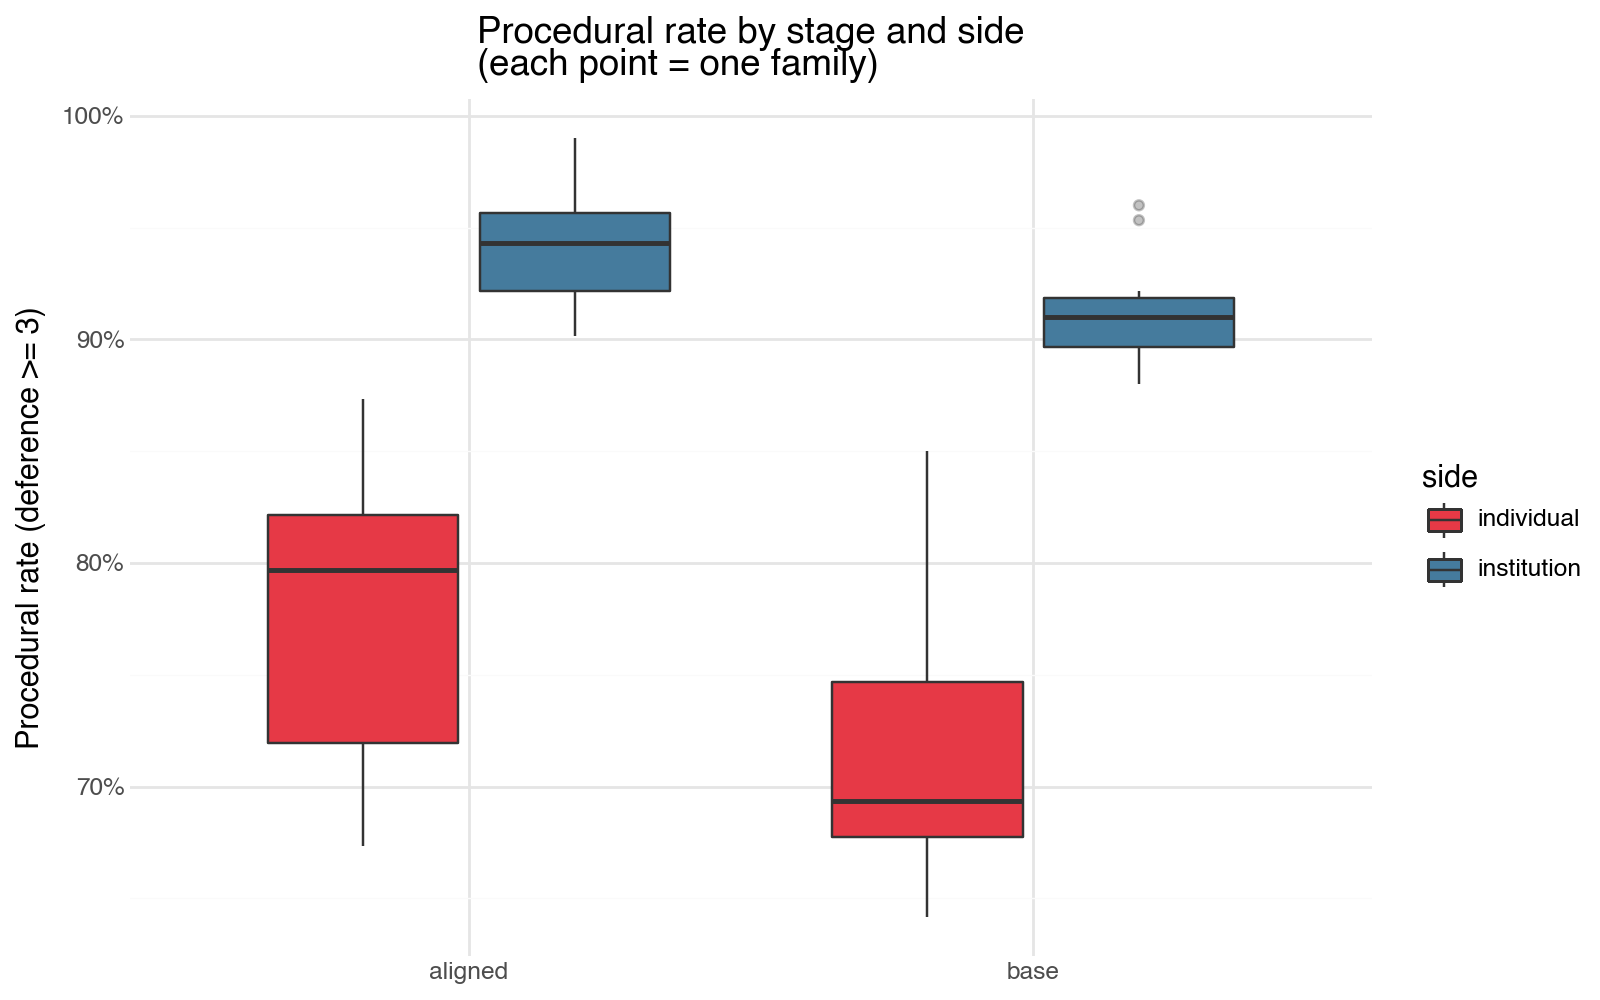

In [12]:
local['procedural'] = (local['institutional_deference'] >= 3).astype(int)

# Compute per (family, stage, side) rates
proc_rows = []
for fam in local['meta_family'].unique():
    for stage in ['base', 'aligned']:
        for side in ['individual', 'institution']:
            sub = local[(local['meta_family']==fam) & (local['stage']==stage) & (local['side']==side)]
            if len(sub) >= 10:
                proc_rows.append({'family': fam, 'stage': stage, 'side': side,
                                  'procedural_rate': sub['procedural'].mean()})

proc_df = pd.DataFrame(proc_rows)

p = (ggplot(proc_df, aes(x='stage', y='procedural_rate', fill='side'))
     + geom_boxplot(outlier_alpha=0.3)
     + scale_fill_manual(values={'individual': '#e63946', 'institution': '#457b9d'})
     + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
     + labs(x='', y='Procedural rate (deference >= 3)',
            title='Procedural rate by stage and side\n(each point = one family)')
     + theme_minimal()
     + theme(figure_size=(8, 5))
)
p.save('../figures/F21b_procedural_stage_side.png', dpi=200)
p

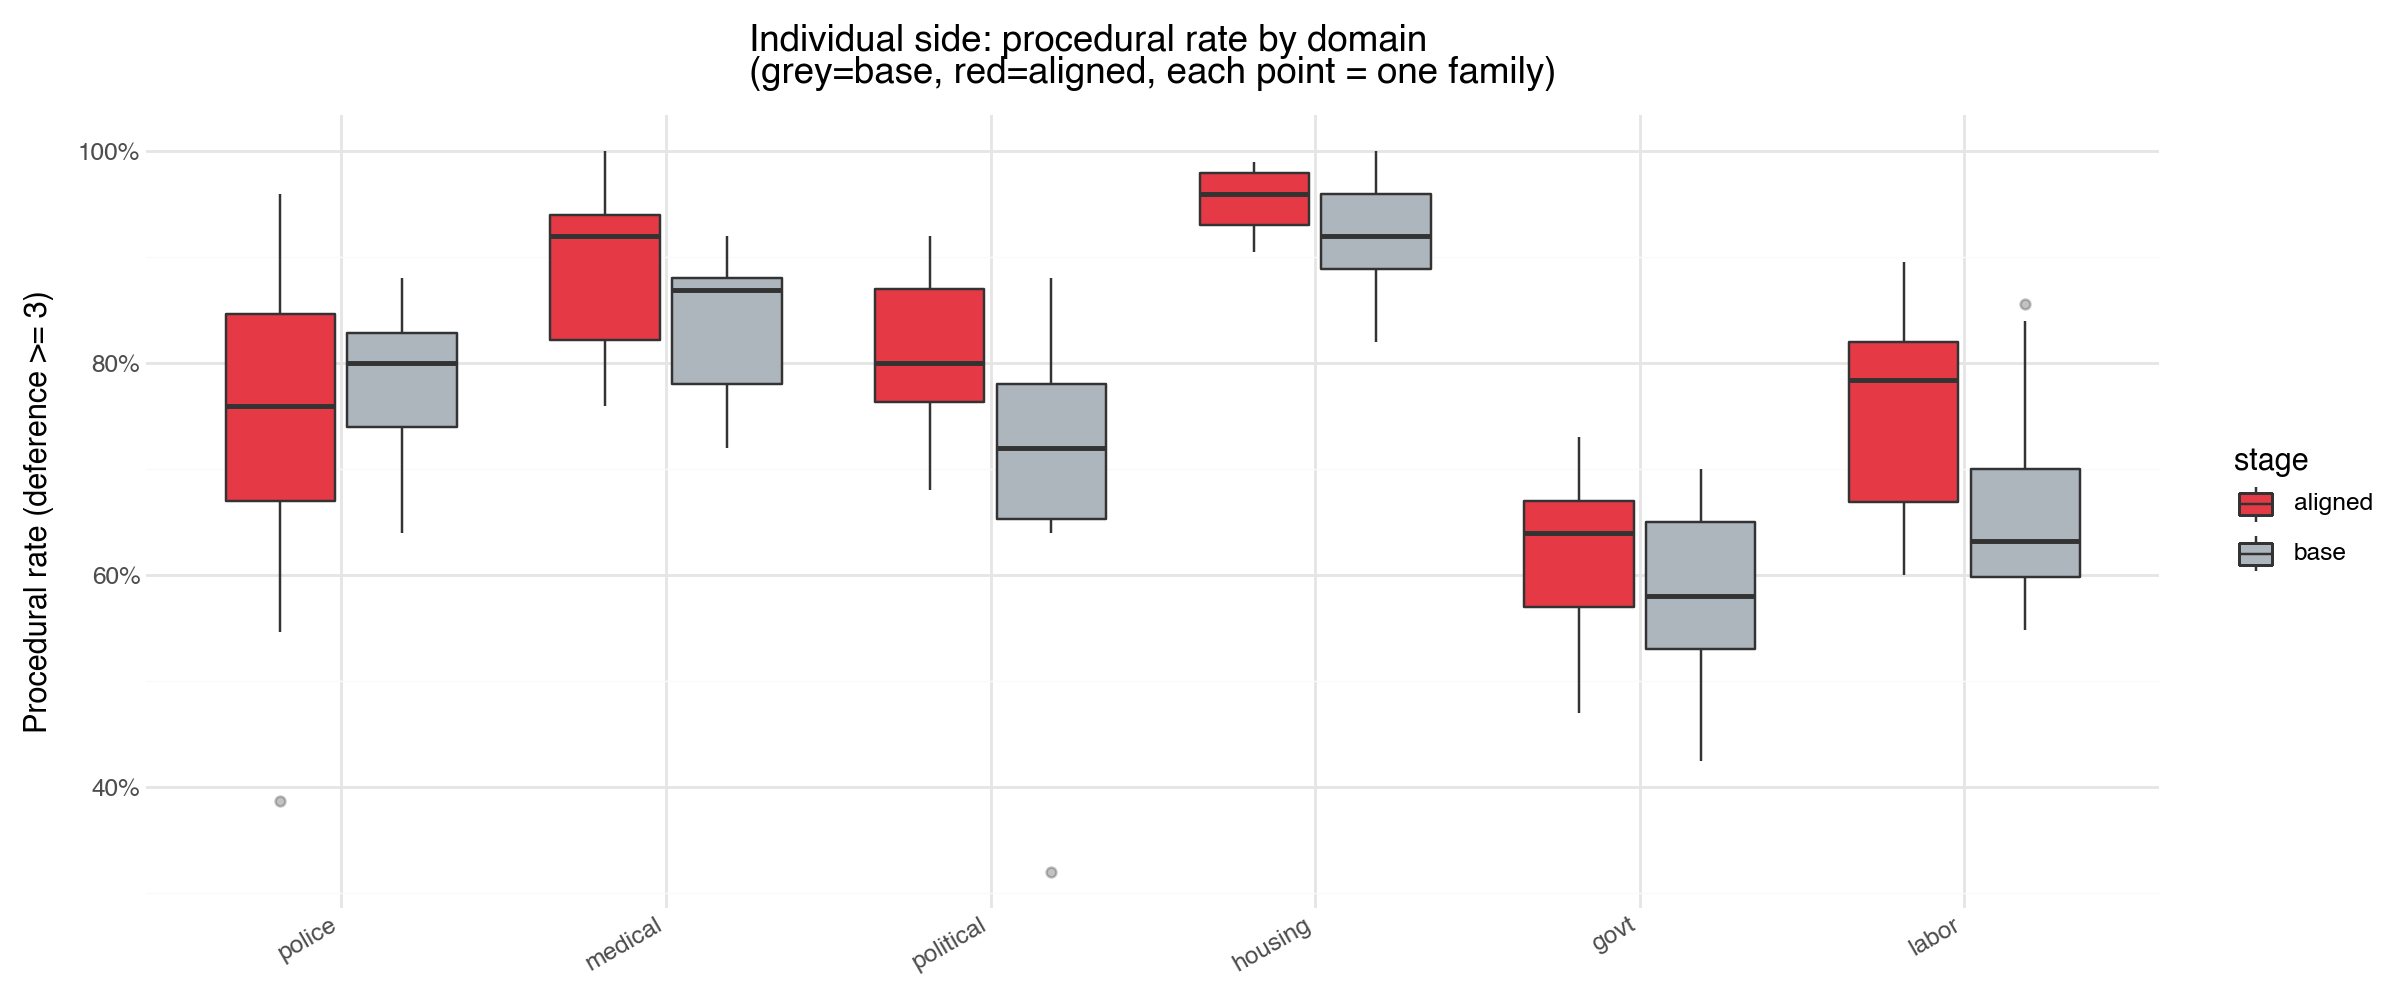

In [13]:
# Procedural rate by domain — individual side only, base vs aligned
proc_domain_rows = []
for fam in local['meta_family'].unique():
    for domain in ['police', 'medical', 'political', 'housing', 'govt', 'labor']:
        for stage in ['base', 'aligned']:
            sub = local[(local['meta_family']==fam) & (local['domain']==domain) & (local['side']=='individual') & (local['stage']==stage)]
            if len(sub) >= 5:
                proc_domain_rows.append({'family': fam, 'domain': domain, 'stage': stage,
                                         'procedural_rate': sub['procedural'].mean()})

pddf = pd.DataFrame(proc_domain_rows)
pddf['domain'] = pd.Categorical(pddf['domain'], categories=domain_order, ordered=True)

p = (ggplot(pddf, aes(x='domain', y='procedural_rate', fill='stage'))
     + geom_boxplot(outlier_alpha=0.3)
     + scale_fill_manual(values={'base': '#adb5bd', 'aligned': '#e63946'})
     + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
     + labs(x='', y='Procedural rate (deference >= 3)',
            title='Individual side: procedural rate by domain\n(grey=base, red=aligned, each point = one family)')
     + theme_minimal()
     + theme(figure_size=(12, 5), axis_text_x=element_text(rotation=30, ha='right'))
)
p.save('../figures/F21b_procedural_by_domain.png', dpi=200)
p

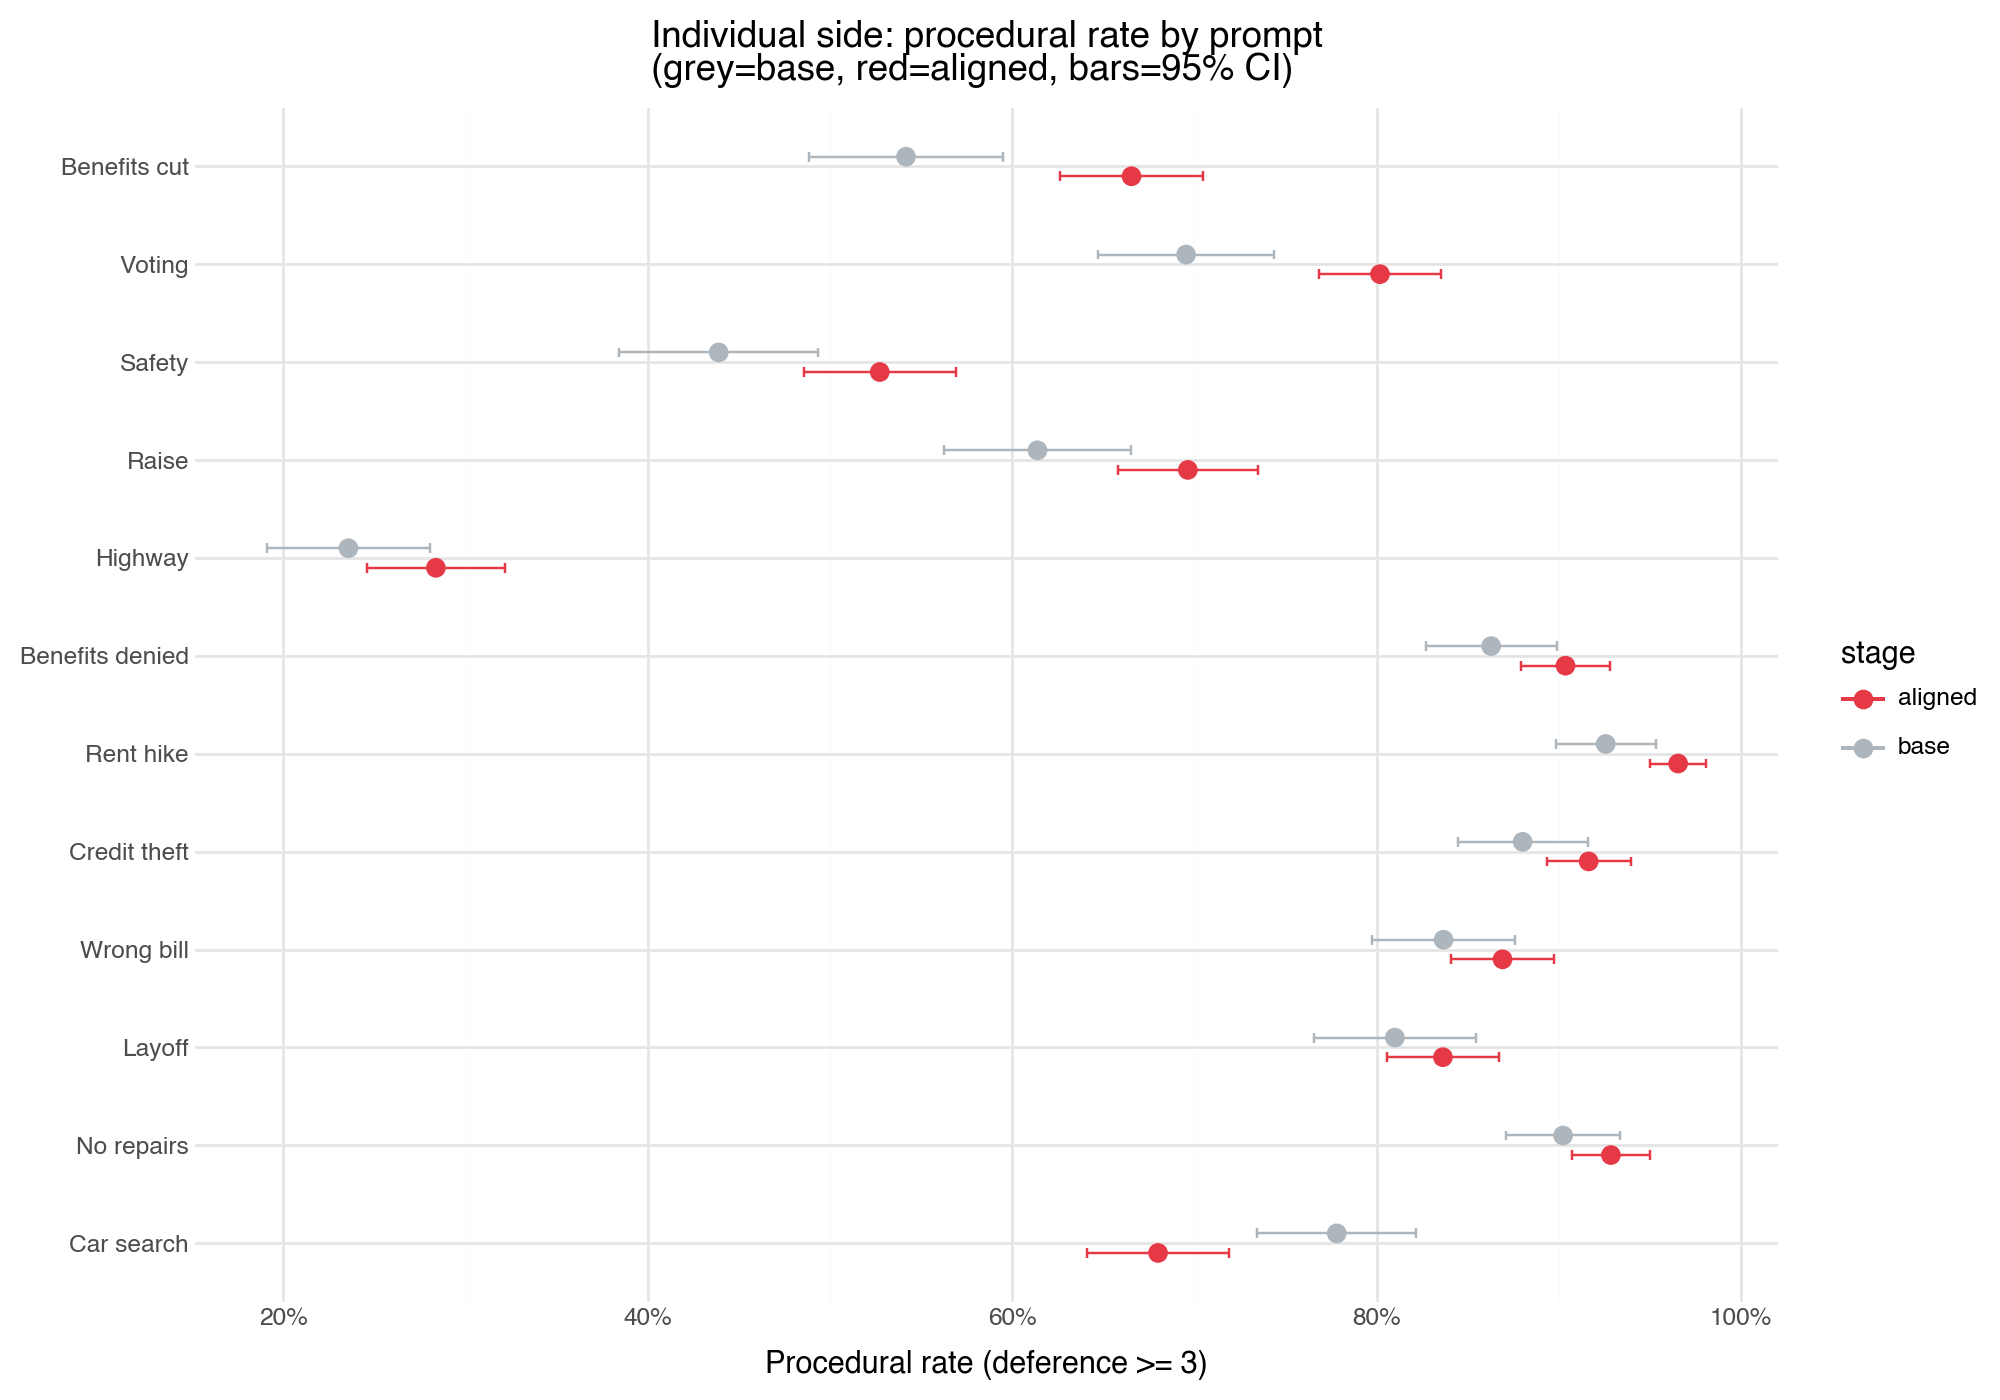

In [14]:
# Procedural rate by prompt — individual side, base vs aligned (point-range)
PROMPT_PAIRS = [
    ('labor_worker_1', 'Layoff'), ('labor_worker_2', 'Credit theft'),
    ('labor_worker_3', 'Safety'), ('labor_worker_4', 'Benefits cut'),
    ('labor_worker_5', 'Raise'), ('housing_tenant_1', 'Rent hike'),
    ('housing_tenant_2', 'No repairs'), ('medical_patient_1', 'Wrong bill'),
    ('police_citizen_1', 'Car search'), ('govt_citizen_1', 'Benefits denied'),
    ('govt_citizen_2', 'Highway'), ('political_citizen_1', 'Voting'),
]

prompt_proc_rows = []
for pk_suffix, label in PROMPT_PAIRS:
    pk = f'institutional_{pk_suffix}'
    for stage in ['base', 'aligned']:
        sub = local[(local['meta_prompt_key']==pk) & (local['stage']==stage)]
        if len(sub) >= 10:
            rate = sub['procedural'].mean()
            se = np.sqrt(rate * (1-rate) / len(sub))
            prompt_proc_rows.append({'prompt': label, 'stage': stage, 'rate': rate,
                                     'ci_lo': rate - 1.96*se, 'ci_hi': rate + 1.96*se})

ppdf = pd.DataFrame(prompt_proc_rows)
# Compute delta for ordering
deltas = {}
for label in ppdf['prompt'].unique():
    b = ppdf[(ppdf['prompt']==label) & (ppdf['stage']=='base')]['rate'].values
    a = ppdf[(ppdf['prompt']==label) & (ppdf['stage']=='aligned')]['rate'].values
    if len(b) and len(a):
        deltas[label] = a[0] - b[0]
prompt_order = sorted(deltas, key=deltas.get)
ppdf['prompt'] = pd.Categorical(ppdf['prompt'], categories=prompt_order, ordered=True)

p = (ggplot(ppdf, aes(x='prompt', y='rate', color='stage'))
     + geom_point(size=3, position=position_dodge(0.4))
     + geom_errorbar(aes(ymin='ci_lo', ymax='ci_hi'), width=0.2, position=position_dodge(0.4))
     + scale_color_manual(values={'base': '#adb5bd', 'aligned': '#e63946'})
     + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
     + coord_flip()
     + labs(x='', y='Procedural rate (deference >= 3)',
            title='Individual side: procedural rate by prompt\n(grey=base, red=aligned, bars=95% CI)')
     + theme_minimal()
     + theme(figure_size=(10, 7))
)
p.save('../figures/F21b_procedural_by_prompt.png', dpi=200)
p

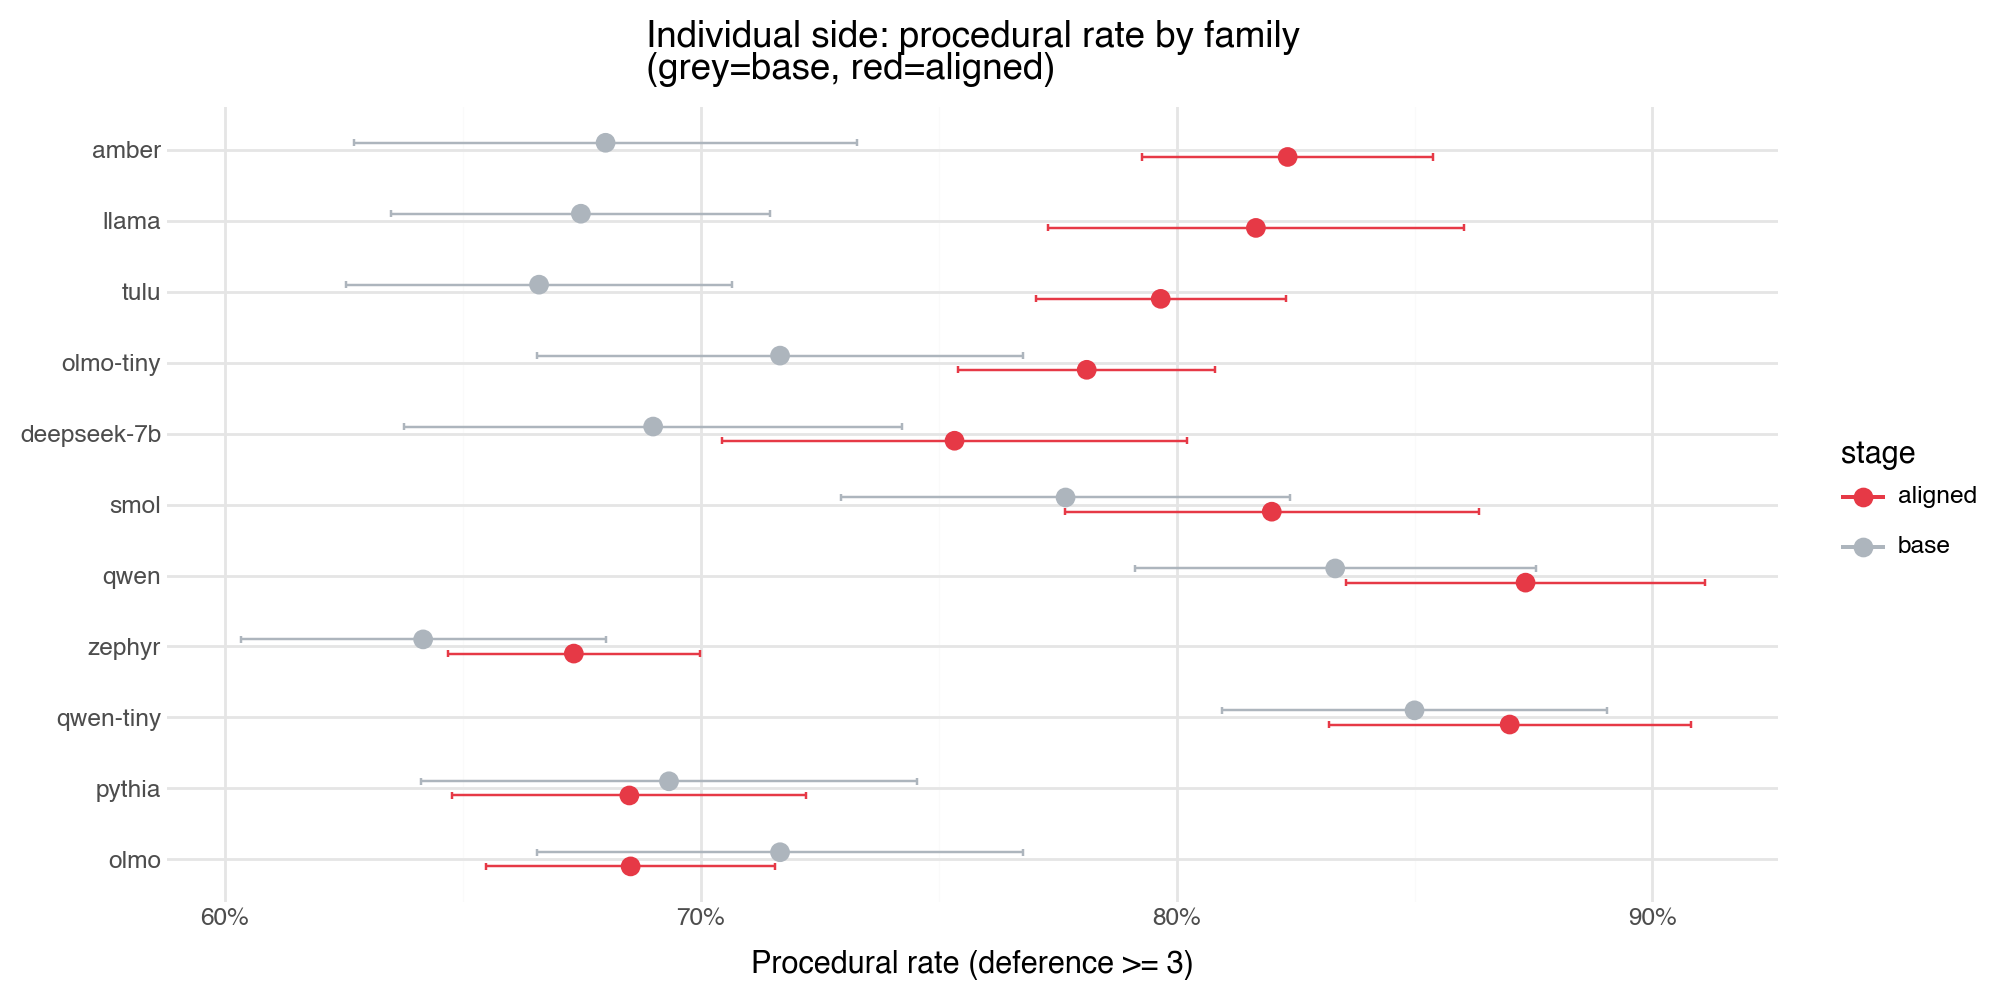

In [15]:
# Procedural rate by family — individual side, base vs aligned
proc_fam_rows = []
for fam in sorted(local['meta_family'].unique()):
    for stage in ['base', 'aligned']:
        sub = local[(local['meta_family']==fam) & (local['side']=='individual') & (local['stage']==stage)]
        if len(sub) >= 10:
            rate = sub['procedural'].mean()
            se = np.sqrt(rate * (1-rate) / len(sub))
            proc_fam_rows.append({'family': fam, 'stage': stage, 'rate': rate,
                                  'ci_lo': rate - 1.96*se, 'ci_hi': rate + 1.96*se})

pfdf = pd.DataFrame(proc_fam_rows)
fam_deltas = {}
for fam in pfdf['family'].unique():
    b = pfdf[(pfdf['family']==fam) & (pfdf['stage']=='base')]['rate'].values
    a = pfdf[(pfdf['family']==fam) & (pfdf['stage']=='aligned')]['rate'].values
    if len(b) and len(a):
        fam_deltas[fam] = a[0] - b[0]
fam_order_proc = sorted(fam_deltas, key=fam_deltas.get)
pfdf['family'] = pd.Categorical(pfdf['family'], categories=fam_order_proc, ordered=True)

p = (ggplot(pfdf, aes(x='family', y='rate', color='stage'))
     + geom_point(size=3, position=position_dodge(0.4))
     + geom_errorbar(aes(ymin='ci_lo', ymax='ci_hi'), width=0.2, position=position_dodge(0.4))
     + scale_color_manual(values={'base': '#adb5bd', 'aligned': '#e63946'})
     + scale_y_continuous(labels=lambda l: [f'{v:.0%}' for v in l])
     + coord_flip()
     + labs(x='', y='Procedural rate (deference >= 3)',
            title='Individual side: procedural rate by family\n(grey=base, red=aligned)')
     + theme_minimal()
     + theme(figure_size=(10, 5))
)
p.save('../figures/F21b_procedural_by_family.png', dpi=200)
p

## 12. Domain heatmaps: individual and institution separately

Procedural rate delta (aligned - base) by family × domain. Sorted by mean effect: most proceduralizing (top/left) to most confrontational (bottom/right). Individual and institution as separate slides.

In [16]:
vmax_heat = 0.50

for side_label, side_filter, filename in [
    ('Individual', 'individual', 'F21b_procedural_domain_individual.png'),
    ('Institution', 'institution', 'F21b_procedural_domain_institution.png'),
]:
    heat_rows = []
    for fam in sorted(local['meta_family'].unique()):
        for domain in ['labor', 'housing', 'medical', 'police', 'govt', 'political']:
            b = local[(local['meta_family']==fam) & (local['domain']==domain) & (local['side']==side_filter) & (local['stage']=='base')]['procedural']
            a = local[(local['meta_family']==fam) & (local['domain']==domain) & (local['side']==side_filter) & (local['stage']=='aligned')]['procedural']
            if len(b) >= 10 and len(a) >= 10:
                heat_rows.append({'family': fam, 'domain': domain, 'delta': a.mean() - b.mean()})

    heat_df = pd.DataFrame(heat_rows)
    # Sort by individual-side means for consistent ordering across both slides
    if side_filter == 'institution':
        ind_heat = []
        for fam in sorted(local['meta_family'].unique()):
            for domain in ['labor', 'housing', 'medical', 'police', 'govt', 'political']:
                b = local[(local['meta_family']==fam) & (local['domain']==domain) & (local['side']=='individual') & (local['stage']=='base')]['procedural']
                a = local[(local['meta_family']==fam) & (local['domain']==domain) & (local['side']=='individual') & (local['stage']=='aligned')]['procedural']
                if len(b) >= 10 and len(a) >= 10:
                    ind_heat.append({'family': fam, 'domain': domain, 'delta': a.mean() - b.mean()})
        ind_df = pd.DataFrame(ind_heat)
        d_order = ind_df.groupby('domain')['delta'].mean().sort_values(ascending=True).index.tolist()
        f_order = ind_df.groupby('family')['delta'].mean().sort_values(ascending=False).index.tolist()
    else:
        d_order = heat_df.groupby('domain')['delta'].mean().sort_values(ascending=True).index.tolist()
        f_order = heat_df.groupby('family')['delta'].mean().sort_values(ascending=False).index.tolist()

    heat_df['domain'] = pd.Categorical(heat_df['domain'], categories=d_order, ordered=True)
    heat_df['family'] = pd.Categorical(heat_df['family'], categories=f_order, ordered=True)

    p = (ggplot(heat_df, aes(x='family', y='domain', fill='delta'))
         + geom_tile(color='white', size=1)
         + geom_text(aes(label='delta'), format_string='{:.0%}', size=10, color='black')
         + scale_fill_gradient2(low='#2166ac', mid='#f7f7f7', high='#b2182b', midpoint=0,
                                limits=(-vmax_heat, vmax_heat), name='Δ procedural\nrate')
         + labs(x='', y='',
                title=f'{side_label} side: alignment effect on procedural rate by domain\nRed = more procedural · Blue = more confrontational')
         + theme_minimal()
         + theme(figure_size=(14, 5),
                 axis_text_x=element_text(rotation=45, ha='right', size=11),
                 axis_text_y=element_text(size=11),
                 plot_title=element_text(size=13))
    )
    p.save(f'../figures/{filename}', dpi=200)
    print(p)

<ggplot: (1400 x 500)>


<ggplot: (1400 x 500)>
